# Spaceship Titanic Competition

### INTRODUCTION

**Goal:** This analysis aims to build a machine learning model that predicts which passengers were transported to an alternate dimension during the Spaceship Titanic's collision in year 2912, using the data of the spaceship's damaged computer system. 

**Data Source:** This dataset is from the [Kaggle Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic). The dataset contains information on approximately 13,000 passengers. 

**Metric:** Accuracy (Target: 0.79+)

**Variables:**

<u>Independent Variables:</u>
- **PassengerId:** Unique identifier of each passenger
- **HomePlanet:** Departure planet 
- **CryoSleep:** Suspended animation status
- **Cabin:** Cabin number
- **Destination:** Destination planet
- **Age:** Passenger age
- **VIP:** VIP service status
- **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck:** Spending amounts
- **Name:** The first and last names of the passenger


<u>Target Variable:</u>
- **Transported:** True if transported to alternate dimension

**Notebook Structure:**
1. Data Overview
2. Data Preparation  
3. Exploratory Data Analysis
4. Statistical Inference
5. Machine Learning Models
6. Conclusion & Improvements

### 1. DATA OVERVIEW

**1.1 Loading Libraries & Dataset**

In [201]:

import pandas as pd
import math, numpy as np, optuna
from sklearn.base import clone
import matplotlib.pyplot as plt
import phik  
import shap
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
import matplotlib.ticker as mtick
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import chi2_contingency, ttest_ind
import optuna
from sklearn.metrics import classification_report
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
from scipy import stats
import joblib
from pprint import pprint
from itertools import combinations
from joblib import parallel_backend
import os, warnings, pandas as pd
from sklearn import set_config
from sklearn.exceptions import ConvergenceWarning
from flaml import AutoML
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Training Data:")
display(df.head())

print("\nTest Data:")
display(test_df.head())

Training Data:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00,False,0.00,0.00,0.00,0.00,0.00,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00,False,109.00,9.00,25.00,549.00,44.00,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00,True,43.00,"3,576.00",0.00,"6,715.00",49.00,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00,False,0.00,"1,283.00",371.00,"3,329.00",193.00,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00,False,303.00,70.00,151.00,565.00,2.00,Willy Santantines,True



Test Data:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.00,False,0.00,0.00,0.00,0.00,0.00,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.00,False,0.00,9.00,0.00,"2,823.00",0.00,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.00,False,0.00,0.00,0.00,0.00,0.00,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.00,False,0.00,"6,652.00",0.00,181.00,585.00,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.00,False,10.00,0.00,635.00,0.00,0.00,Brence Harperez


**1.2 Sample Size**

In [202]:
print(f"Training Data: {df.shape}")
print(f"Test Data: {test_df.shape}")

Training Data: (8693, 14)
Test Data: (4277, 13)


**Training Data:** 8,693 passengers with 13 features + target variable ('Transported') for model training.

**Test Data:** 4,277 passengers with only the 13 features. We'll predict the missing 'Transported' values using our trained model.

**1.3 Variables**

1.3.1 Columns

In [1]:
df.columns

NameError: name 'df' is not defined

As expressed above, the Training Data contains 14 variables.

1.3.2 Data Types

In [203]:
df.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

The Training Data includes both categorical variables and numerical variables. 

1.3.3 Duplicates

In [188]:
df.duplicated().sum()

np.int64(0)

This shows that there are no duplicate rows in the Training Data. 

1.3.4 Missing Values

In [189]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

There are missing values spanning all of the indepedent variables, except PassengerId in the Training Data. In the Data Preparation section below, we will handle these missing values by using imputation techniques. 

1.3.3 Categorical Variables Analysis

In [204]:
print("PassengerId unique values:", 
      [(val, int(df['PassengerId'].value_counts()[val])) for val in df['PassengerId'].unique()[:5]])  # Show first 5 only
print(f"Total unique PassengerIds: {df['PassengerId'].nunique()}")

print("\nHomePlanet unique values:", 
      [(val, int(df['HomePlanet'].value_counts()[val])) for val in df['HomePlanet'].unique() if pd.notna(val)])

print("\nCryoSleep unique values:", 
      [(val, int(df['CryoSleep'].value_counts()[val])) for val in df['CryoSleep'].unique() if pd.notna(val)])

print("\nCabin unique values (first 5):", 
      [(val, int(df['Cabin'].value_counts()[val])) for val in df['Cabin'].unique()[:5] if pd.notna(val)])
print(f"Total unique Cabins: {df['Cabin'].nunique()}")

print("\nDestination unique values:", 
      [(val, int(df['Destination'].value_counts()[val])) for val in df['Destination'].unique() if pd.notna(val)])

print("\nVIP unique values:", 
      [(val, int(df['VIP'].value_counts()[val])) for val in df['VIP'].unique() if pd.notna(val)])

print("\nName unique values (first 5):", 
      [(val, int(df['Name'].value_counts()[val])) for val in df['Name'].unique()[:5] if pd.notna(val)])
print(f"Total unique Names: {df['Name'].nunique()}")


PassengerId unique values: [('0001_01', 1), ('0002_01', 1), ('0003_01', 1), ('0003_02', 1), ('0004_01', 1)]
Total unique PassengerIds: 8693

HomePlanet unique values: [('Europa', 2131), ('Earth', 4602), ('Mars', 1759)]

CryoSleep unique values: [(False, 5439), (True, 3037)]

Cabin unique values (first 5): [('B/0/P', 1), ('F/0/S', 1), ('A/0/S', 2), ('F/1/S', 1), ('F/0/P', 1)]
Total unique Cabins: 6560

Destination unique values: [('TRAPPIST-1e', 5915), ('PSO J318.5-22', 796), ('55 Cancri e', 1800)]

VIP unique values: [(False, 8291), (True, 199)]

Name unique values (first 5): [('Maham Ofracculy', 1), ('Juanna Vines', 1), ('Altark Susent', 1), ('Solam Susent', 1), ('Willy Santantines', 1)]
Total unique Names: 8473


* PassengerID holds 8693 unique categories and be used to extract group information in feature engineering as the first 4 digits signify a group. After GroupId is created, PassenderId will be dropped.
* Cabin contains multiple pieces of information regarding the deck, the cabin number and the side, which will benefit from feature engineering before using for analysis. 
* Name provides the first and last name of each passenger. This variable will be dropped as it does not contain such useful information for analysis.



### 2. DATA PREPARATION

**Anomaly Detection**

Here we explore anomalies in the numerical features of the Training Data.

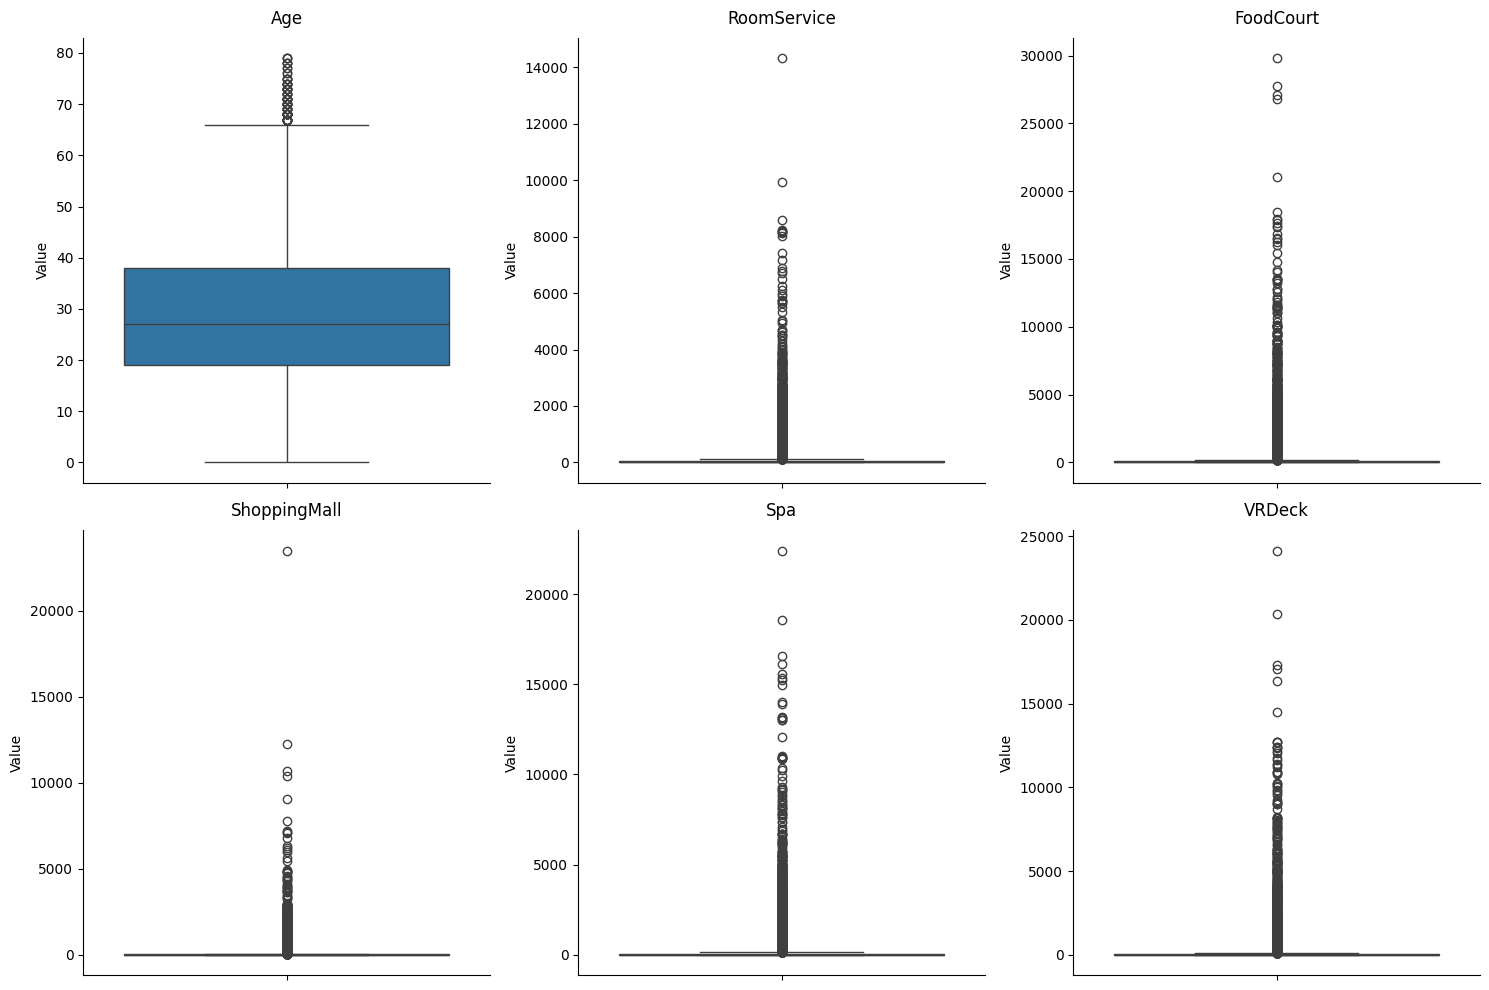

In [191]:
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
_, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df[col], ax=axes[i], showfliers=True)
    axes[i].set_title(col, pad=10)
    axes[i].set_ylabel('Value')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(False)

plt.tight_layout()
plt.show()

It seems we have a lot of outliers here. I will print a summary of the outliers below for further investigation. 

In [192]:
total_outliers = 0
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    if col == 'Age':
        lower_bound = q1 - 1.5 * iqr
    else:
        lower_bound = 0  
    upper_bound = q3 + 1.5 * iqr
    outliers = df[col][(df[col] < lower_bound) | (df[col] > upper_bound)]
    total_outliers += len(outliers)
    
    print(f"\n{col}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Normal range: {max(0, lower_bound):.2f} to {upper_bound:.2f}")
    print(f"Actual range: {df[col].min():.2f} to {df[col].max():.2f}")
    print(f"Median of outliers: {outliers.median():.2f}")
    print(f"Percentage of zeros: {(df[col] == 0).mean()*100:.1f}%")
    print(f"Percentage of data that are outliers: {(len(outliers)/len(df[col]))*100:.1f}%")


Age:
Number of outliers: 77
Normal range: 0.00 to 66.50
Actual range: 0.00 to 79.00
Median of outliers: 70.00
Percentage of zeros: 2.0%
Percentage of data that are outliers: 0.9%

RoomService:
Number of outliers: 1861
Normal range: 0.00 to 117.50
Actual range: 0.00 to 14327.00
Median of outliers: 701.00
Percentage of zeros: 64.2%
Percentage of data that are outliers: 21.4%

FoodCourt:
Number of outliers: 1823
Normal range: 0.00 to 190.00
Actual range: 0.00 to 29813.00
Median of outliers: 914.00
Percentage of zeros: 62.8%
Percentage of data that are outliers: 21.0%

ShoppingMall:
Number of outliers: 1829
Normal range: 0.00 to 67.50
Actual range: 0.00 to 23492.00
Median of outliers: 576.00
Percentage of zeros: 64.3%
Percentage of data that are outliers: 21.0%

Spa:
Number of outliers: 1788
Normal range: 0.00 to 147.50
Actual range: 0.00 to 22408.00
Median of outliers: 710.50
Percentage of zeros: 61.2%
Percentage of data that are outliers: 20.6%

VRDeck:
Number of outliers: 1809
Normal r

* Spending-related features showed significant outliers (around 21% for each spending category) and a high percentage of zeros. Within the feature engineering part, I will create an extreme spender variable identifying the highest 1% of total spenders. 
* Additionally, to handle the extreme spending values, I will apply log transformations to all spending features and total spending, making the distribution more normal and manageable for our model. 
* For age, which showed relatively few outliers (0.9%) but could benefit from more interpretable groupings, I'll create categorical age bands. 

**Imputation**

In [205]:
class ImputationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.fill_values = {}
    
    def fit(self, X, y=None):
        for col in X.columns:
            if X[col].dtype == 'object':
                self.fill_values[col] = X[col].mode()[0]
            else:
                self.fill_values[col] = X[col].median()
        return self
    
    def transform(self, X):
        return X.fillna(self.fill_values)

imputation_pipeline = Pipeline([
    ('imputer', ImputationTransformer())
])

df = imputation_pipeline.fit_transform(df)
test_df = imputation_pipeline.transform(test_df)

print(f"Training missing values: {df.isnull().sum().sum()}")
print(f"Test missing values: {test_df.isnull().sum().sum()}")

Training missing values: 0
Test missing values: 0


Based on the missing values in the Data Overview, I applied simple imputation: numerical columns are filled with their median, and categorical columns with their most frequent value (mode). This is implemented in a scikit-learn pipeline so the imputer is fit on the training data and the same rules are applied consistently to both the training and test sets.

**Feature Engineering**

In [206]:
def engineer_features(data):
    data['Deck'] = data['Cabin'].str.split('/').str[0]
    data['Cabin_Number'] = data['Cabin'].str.split('/').str[1].astype(float)
    data['Side'] = data['Cabin'].str.split('/').str[2]
    
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    data['Total_Spending'] = data[spending_cols].sum(axis=1)
    data['No_Spending'] = (data['Total_Spending'] == 0).astype(int)
    spending_threshold = data['Total_Spending'].quantile(0.99)
    data['Extreme_Spender'] = (data['Total_Spending'] > spending_threshold).astype(int)

    age_bins = [0, 12, 18, 65, float('inf')]
    age_labels = ['Child', 'Teen', 'Adult', 'Senior']
    data['Age_Group'] = pd.cut(data['Age'], 
                              bins=age_bins, 
                              labels=age_labels, 
                              right=False)
    
    data['Group_ID'] = data['PassengerId'].str.split('_').str[0]
    data['Group_Size'] = data.groupby('Group_ID')['PassengerId'].transform('count')
    data['Is_Alone'] = (data['Group_Size'] == 1).astype(int)
    
    return data

df = engineer_features(df)
test_df = engineer_features(test_df)

df.drop(columns=['Cabin', 'PassengerId', 'Name'], inplace=True)
test_df.drop(columns=['Cabin', 'Name'], inplace=True)  
print("Training Data:")
display(df.head())
print("Test Data:")
display(test_df.head())

Training Data:


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,Deck,Cabin_Number,Side,Total_Spending,No_Spending,Extreme_Spender,Age_Group,Group_ID,Group_Size,Is_Alone
0,Europa,False,TRAPPIST-1e,39.00,False,0.00,0.00,0.00,0.00,0.00,...,B,0.00,P,0.00,1,0,Adult,0001,1,1
1,Earth,False,TRAPPIST-1e,24.00,False,109.00,9.00,25.00,549.00,44.00,...,F,0.00,S,736.00,0,0,Adult,0002,1,1
2,Europa,False,TRAPPIST-1e,58.00,True,43.00,"3,576.00",0.00,"6,715.00",49.00,...,A,0.00,S,"10,383.00",0,0,Adult,0003,2,0
3,Europa,False,TRAPPIST-1e,33.00,False,0.00,"1,283.00",371.00,"3,329.00",193.00,...,A,0.00,S,"5,176.00",0,0,Adult,0003,2,0
4,Earth,False,TRAPPIST-1e,16.00,False,303.00,70.00,151.00,565.00,2.00,...,F,1.00,S,"1,091.00",0,0,Teen,0004,1,1


Test Data:


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,...,Deck,Cabin_Number,Side,Total_Spending,No_Spending,Extreme_Spender,Age_Group,Group_ID,Group_Size,Is_Alone
0,0013_01,Earth,True,TRAPPIST-1e,27.00,False,0.00,0.00,0.00,0.00,...,G,3.00,S,0.00,1,0,Adult,0013,1,1
1,0018_01,Earth,False,TRAPPIST-1e,19.00,False,0.00,9.00,0.00,"2,823.00",...,F,4.00,S,"2,832.00",0,0,Adult,0018,1,1
2,0019_01,Europa,True,55 Cancri e,31.00,False,0.00,0.00,0.00,0.00,...,C,0.00,S,0.00,1,0,Adult,0019,1,1
3,0021_01,Europa,False,TRAPPIST-1e,38.00,False,0.00,"6,652.00",0.00,181.00,...,C,1.00,S,"7,418.00",0,0,Adult,0021,1,1
4,0023_01,Earth,False,TRAPPIST-1e,20.00,False,10.00,0.00,635.00,0.00,...,F,5.00,S,645.00,0,0,Adult,0023,1,1


I feature engineered several variables to create more informative features: 
* Cabin (e.g., "B/2/P") was split into into deck letter, cabin number, and ship side to capture location-based patterns. 
* Spending behavior was summarised by creating a total spending sum across all services (Total_Spending), flagging non-spenders (No_Spending) where 1 means has spent and 1 means has not spent, and identifying the top 1% as extreme spenders (Extreme_Spender) where 0 means normal spender and 1 means extreme spender.
* Age was categorised into meaningful groups into the Age_Group feature (Child: 0-12, Teen: 13-18, Adult: 19-65, Senior: 65+).
* Passenger groups were identified using the PassengerId format to create features for Group_ID, Group_Size and solo traveler status (Is_Alone) where 0 means travelling in a group and 1 means travelling solo. 

After extracting these new features, we dropped the original Cabin, PassengerId, and Name columns, applying this consistently across both Training and Test Data.

**Splitting the Training Data**

In [165]:
X = df.drop(['Transported'], axis=1)
y = df['Transported']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42, stratify=y)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (6954, 20)
y_train: (6954,)

Test set:
X_test: (1739, 20)
y_test: (1739,)


The data has been split into training (80%, 6954 samples) and test (20%, 1739 samples) sets using stratification on the 'Transported' variable to maintain the same proportion of Transported cases in both sets. This split is done before any EDA to prevent data leakage and ensure unbiased model evaluation.

### 3. EXPLORATORY DATA ANALYSIS

**3.1 Statistical Summary**

In [50]:
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numerical_cols].describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin_Number,Total_Spending,No_Spending,Extreme_Spender,Group_Size,Is_Alone
count,"6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00","6,954.00"
mean,28.65,225.35,442.59,165.90,302.21,290.51,601.16,"1,426.55",0.42,0.01,2.03,0.55
std,14.35,670.06,"1,586.02",542.68,"1,130.62","1,097.86",505.17,"2,755.56",0.49,0.09,1.59,0.50
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,19.00,0.00,0.00,0.00,0.00,0.00,173.00,0.00,0.00,0.00,1.00,0.00
50%,27.00,0.00,0.00,0.00,0.00,0.00,449.00,715.00,0.00,0.00,1.00,1.00
75%,37.00,43.00,54.75,20.00,48.00,36.75,974.00,"1,442.00",1.00,0.00,3.00,1.00
max,79.00,"14,327.00","29,813.00","12,253.00","22,408.00","20,336.00","1,893.00","35,987.00",1.00,1.00,8.00,1.00


* Age ranges from 0 to 79 years old, with a mean of 29 and median of 27, suggesting a young passenger population.
* RoomService, FoodCourt, ShoppingMall, Spa and VRDeck all show significantly minimal spending patterns among passengers as median (50%) is at 0.
* Total_Spending shows extreme variation, ranging from 0 to 35,987, with about 42% of passengers making no purchases at all.
* Only 1% of passengers are marked as Extreme_Spenders (0.01), confirming our top 1% threshold is working.
* Group_Size varies from 1 to 8 passengers, with a mean of 2, suggesting most passengers travel in small groups.
* The Is_Alone indicator shows that 55% of passengers are travelling solo. 
* Cabin_Number distribution (from 0 to 1893) suggests a large ship with extensive cabin numbering system.

**3.2 Distribution of Independent Variables**

3.2.1 Distribution of Numerical Variables

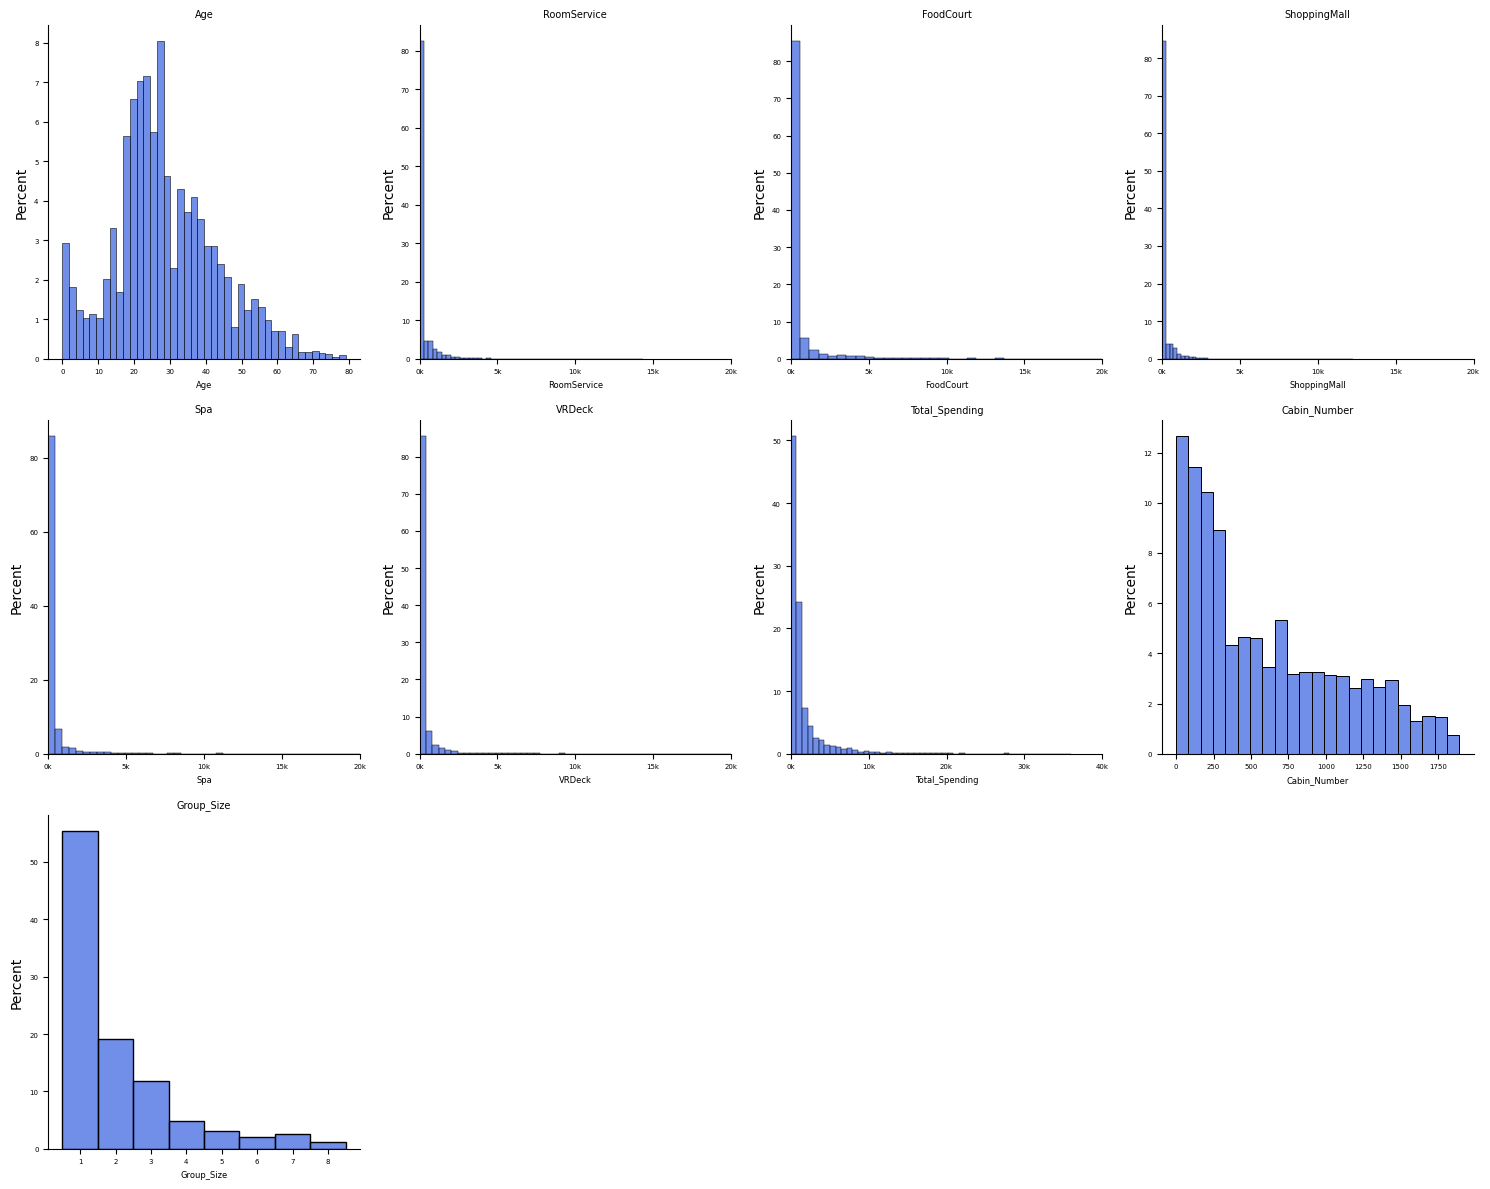

In [51]:
warnings.filterwarnings('ignore')
continuous_vars = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
                  'Total_Spending', 'Cabin_Number', 'Group_Size']
fig, axes = plt.subplots((len(continuous_vars) + 3) // 4, 4, figsize=(15, 12))
axes = axes.ravel()
spending_vars = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for idx, var in enumerate(continuous_vars):
    if var in spending_vars or var == 'Total_Spending':
        zero_pct = (X_train[var] == 0).mean() * 100
        sns.histplot(data=X_train[var], bins=50, color='royalblue', 
                    stat='percent', ax=axes[idx])
        max_val = 40000 if var == 'Total_Spending' else 20000
        axes[idx].set_xlim(0, max_val)
        axes[idx].set_xticks([i * max_val/4 for i in range(5)])
        axes[idx].set_xticklabels([f'{int(i/1000)}k' for i in axes[idx].get_xticks()])
        axes[idx].set_title(f'{var}', fontsize=7)
        axes[idx].set_ylabel('Percent')
    else:
        stat_type = 'percent'
        sns.histplot(data=X_train, x=var, kde=False, discrete=(var=='Group_Size'),
                    color='royalblue', stat=stat_type, ax=axes[idx])
        axes[idx].set_title(f'{var}', fontsize=7)
    axes[idx].set_xlabel(var, fontsize=6)
    axes[idx].tick_params(axis='both', labelsize=5)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
[fig.delaxes(ax) for ax in axes[len(continuous_vars):]]
plt.tight_layout()
plt.show()

The plots cover spending (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck), passenger traits (Age, Group_Size), Cabin_Number, and Total_Spending. All spending variables and Total_Spending are strongly right-skewed, most passengers spend little, with a small tail of heavy spenders. Group_Size is concentrated at 1, dropping quickly for larger parties. Age is centered in the 20s–30s with fewer very young or older passengers. 

3.2.2 Distribution of Binary Variables

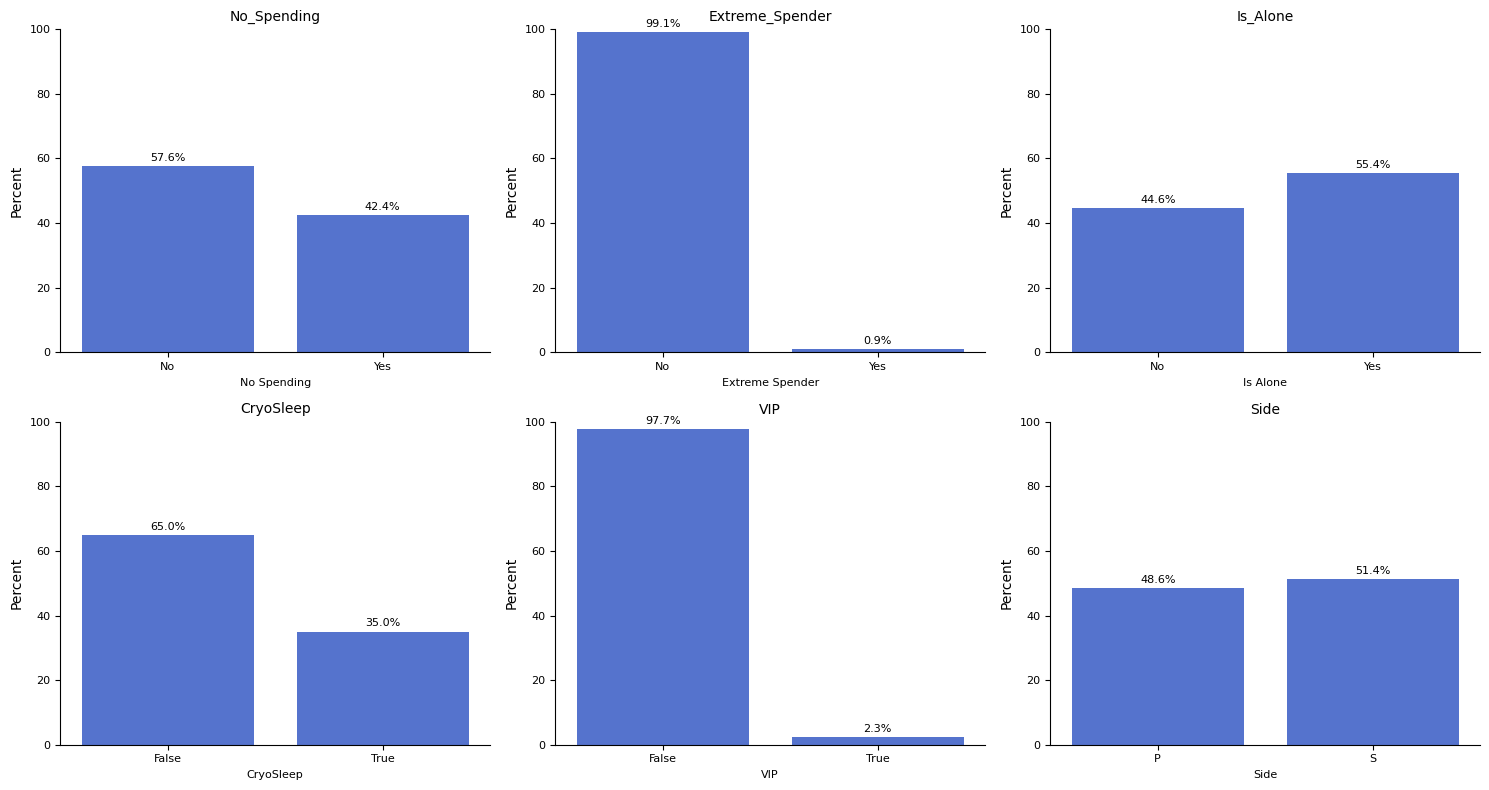

In [52]:
binary_vars = ['No_Spending', 'Extreme_Spender', 'Is_Alone', 'CryoSleep', 'VIP', 'Side']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for idx, var in enumerate(binary_vars):
    percentages = X_train[var].value_counts().sort_index() / len(X_train) * 100
    if var == 'Side':
        labels = ['P', 'S'] 
    elif var == 'CryoSleep' or var == 'VIP':
        labels = ['False', 'True']
    else:
        labels = ['No', 'Yes']
    sns.barplot(x=labels, y=percentages.values, color='royalblue', ax=axes[idx])
    for i, p in enumerate(percentages):
        axes[idx].text(i, p + 1, f'{p:.1f}%', ha='center', va='bottom', fontsize=8)
    axes[idx].set_title(var, fontsize=10)
    axes[idx].set_ylabel('Percent')
    axes[idx].set_ylim(0, 100)
    axes[idx].tick_params(axis='both', labelsize=8)
    axes[idx].set_xlabel(var.replace('_', ' '), fontsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

About 57% of passengers are No_Spending and 43% spent something. Extreme_Spender is rare (~1%), consistent with the low VIP rate (~2%). Is_Alone vs not and cabin Side (P vs S) show no strong skew while CryoSleep is less common, at roughly 35% true vs 65% false.


3.2.3 Distribution of Categorical Variables

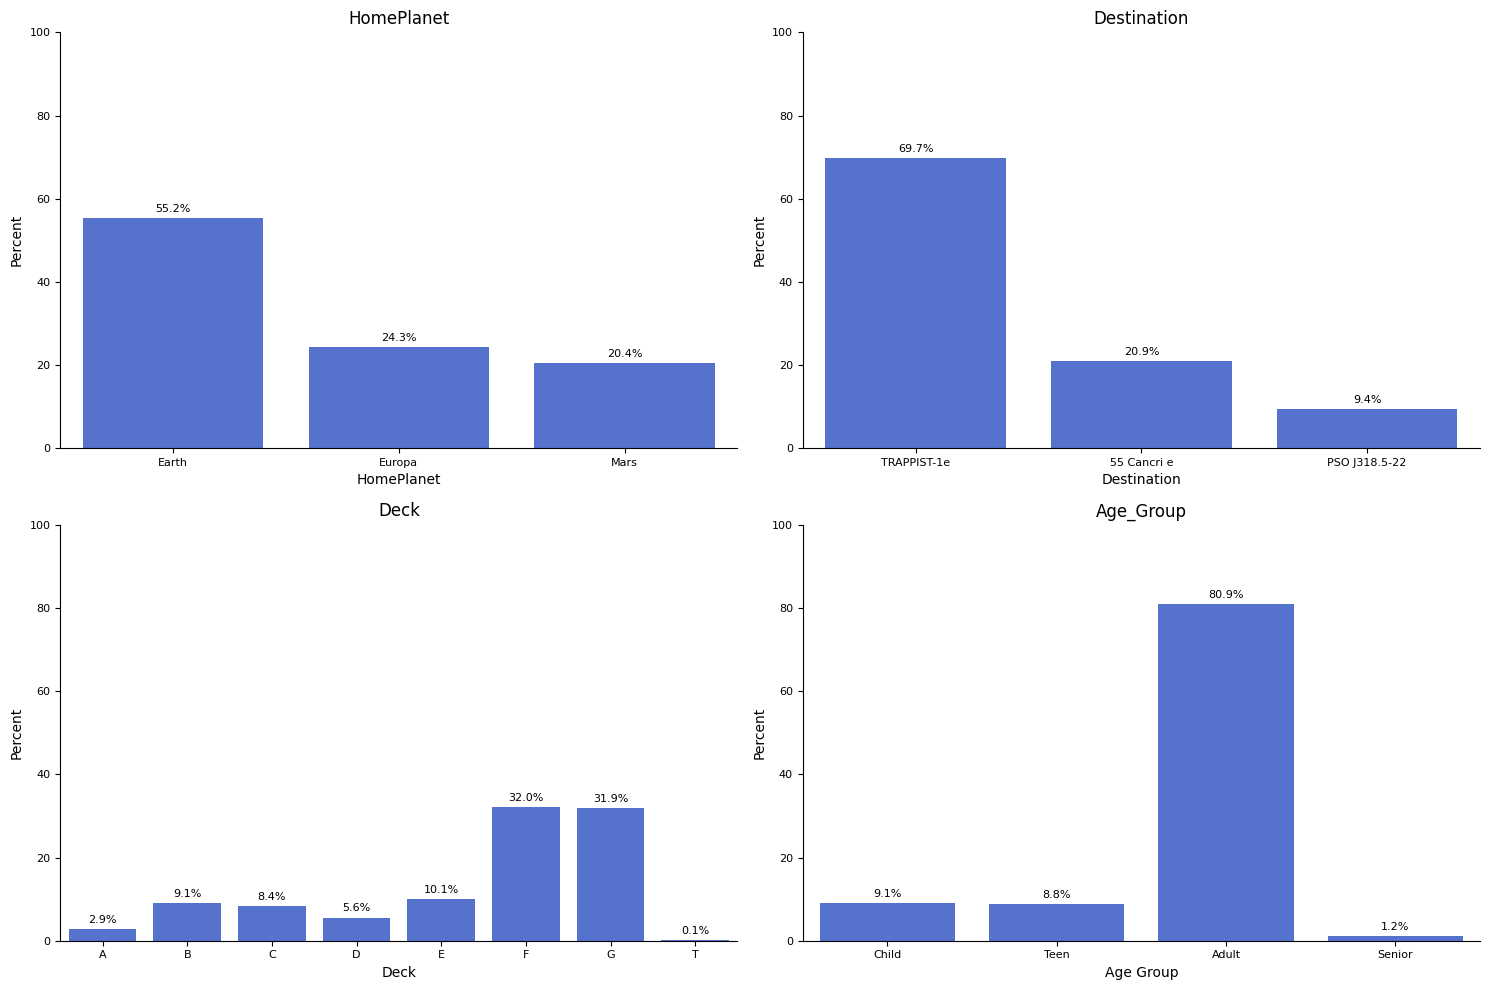

In [53]:
warnings.filterwarnings('ignore')
categorical_vars = ['HomePlanet', 'Destination', 'Deck', 'Age_Group']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
special_orders = {
    'Age_Group': ['Child', 'Teen', 'Adult', 'Senior'],
    'Deck': sorted(X_train['Deck'].unique())
}
for idx, var in enumerate(categorical_vars):
    if var in special_orders:
        order = special_orders[var]
        percentages = X_train[var].value_counts()[order] / len(X_train) * 100
    else:
        percentages = X_train[var].value_counts(normalize=True) * 100
    sns.barplot(x=percentages.index, y=percentages.values, color='royalblue', ax=axes[idx])
    for i, p in enumerate(percentages):
        axes[idx].text(i, p + 1, f'{p:.1f}%', ha='center', va='bottom', fontsize=8)
    axes[idx].set(title=var, xlabel=var.replace('_', ' '), ylabel='Percent', ylim=(0, 100))
    axes[idx].tick_params(axis='both', labelsize=8)
    axes[idx].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Most passengers come from Earth (~55%), with Europa (~24%) and Mars (~20%) making up the rest. Destinations are dominated by TRAPPIST-1e (~70%), then 55 Cancri e (~21%) and PSO J318.5-22 (~9%). Cabin placement is concentrated on Decks F and G (~32% each; ~63% combined), while other decks are each under ~10%. The cohort is strongly Adult (~81%), with Child/Teen ~9% each and Senior ~1%.


**3.3 Distribution of Target Variable**

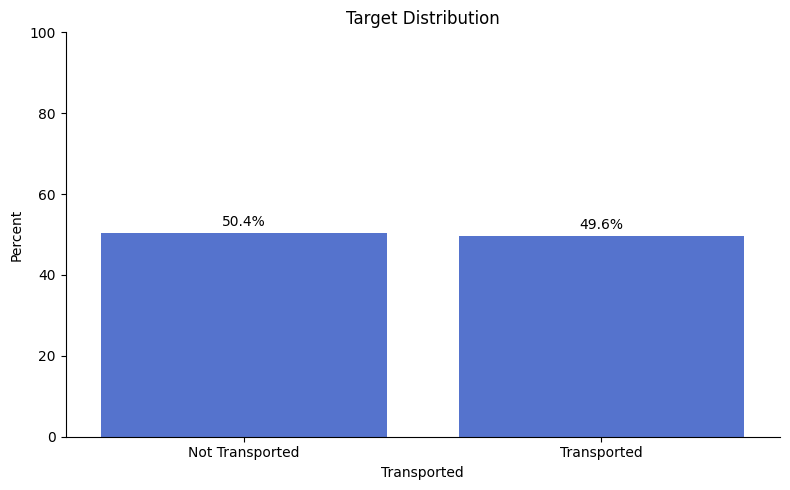

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
percentages = y_train.value_counts(normalize=True) * 100
sns.barplot(x=['Not Transported', 'Transported'], y=percentages.values, color='royalblue', ax=ax)
for i, p in enumerate(percentages):
    ax.text(i, p + 1, f'{p:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Target Distribution', fontsize=12)
ax.set_xlabel('Transported', fontsize=10)
ax.set_ylabel('Percent', fontsize=10)
ax.set_ylim(0, 100)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

This shows that our Target Variable has a balanced class distribution, which means no techniques for imbalanced sets will need to be applied. 

**3.4 Relationship between Independent Variables and Target Variable**

3.4.1 Relationship between Numerical Variables and Target Variable

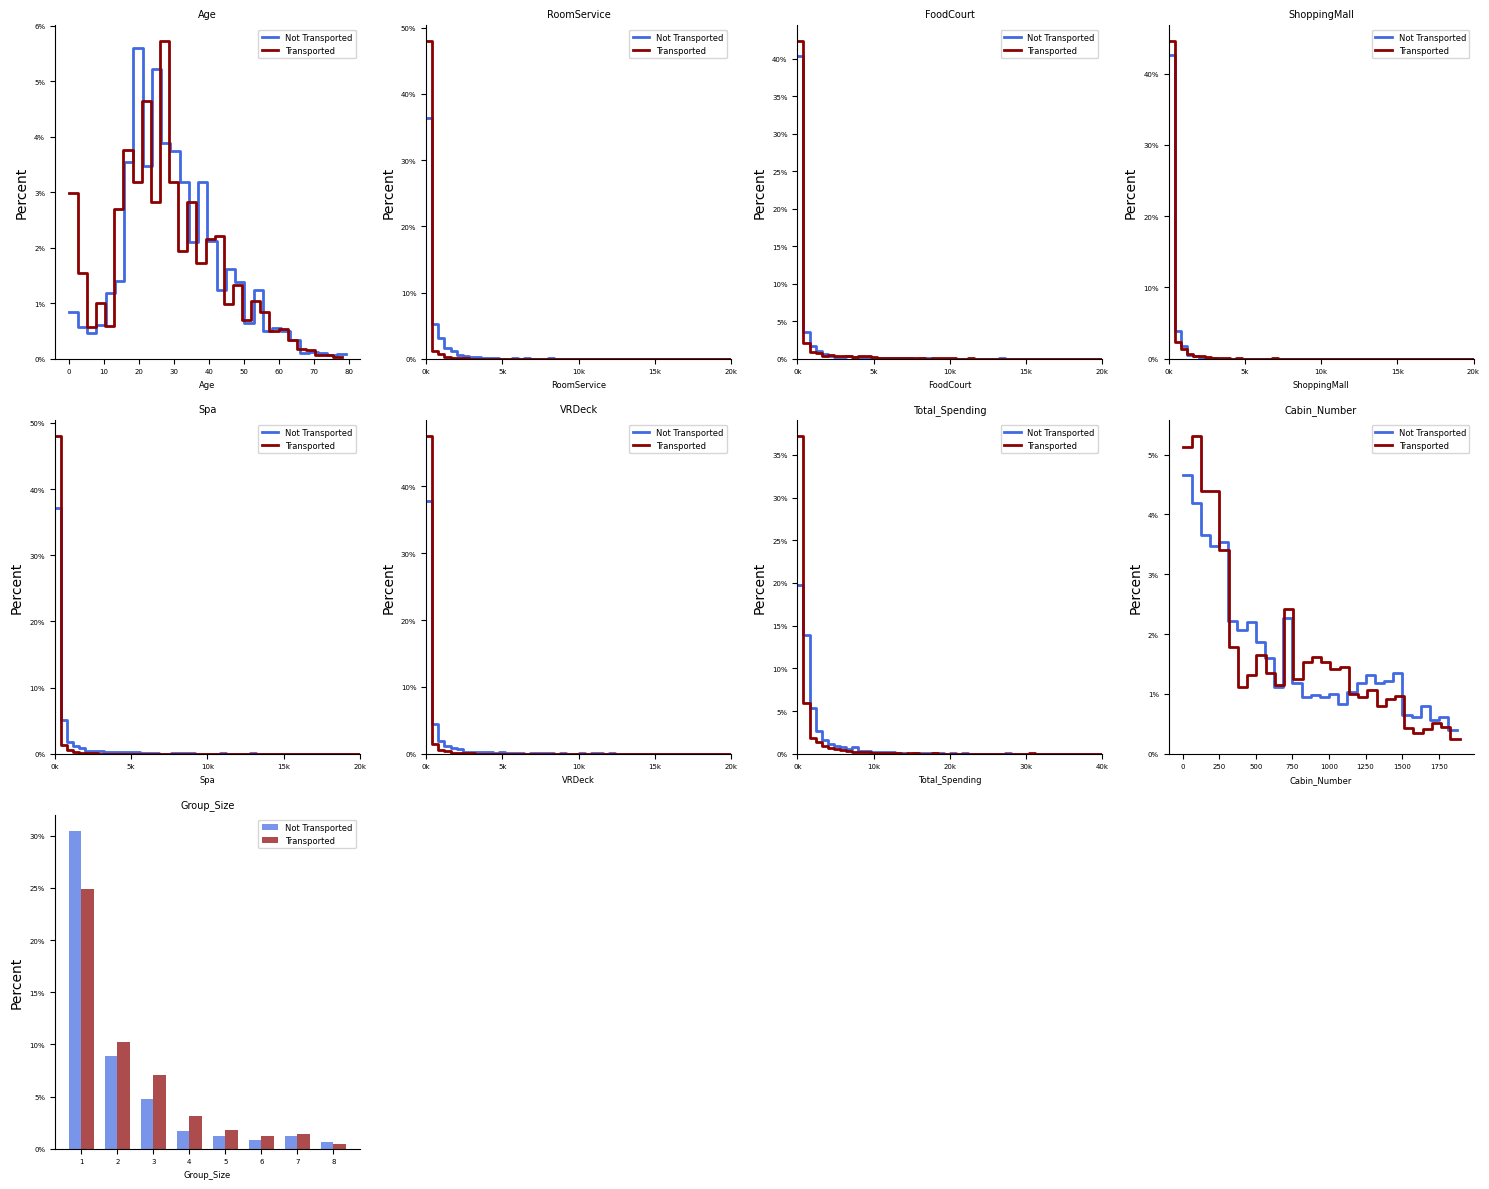

In [99]:
warnings.filterwarnings('ignore')
continuous_vars = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
                  'Total_Spending', 'Cabin_Number', 'Group_Size']
spending_vars = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots((len(continuous_vars) + 3) // 4, 4, figsize=(15, 12))
axes = axes.ravel()
temp_df = X_train.copy()
temp_df['Transported'] = y_train

def plot_histogram(data, var, ax, bin_range=None, bins=30):
    for transported, color in [(False, 'royalblue'), (True, 'darkred')]:
        subset = data[data['Transported'] == transported][var].dropna()
        weights = np.full(len(subset), 100.0 / len(data[var].dropna()))
        sns.histplot(x=subset, bins=bins, weights=weights, binrange=bin_range,
                    stat='count', element='step', fill=False, 
                    label=f'{"" if transported else "Not "}Transported',
                    color=color, linewidth=2, ax=ax)
for idx, var in enumerate(continuous_vars):
    if var == 'Group_Size':
        df_g = temp_df.dropna(subset=['Group_Size'])
        group_sizes = sorted(df_g['Group_Size'].unique())
        for transported, offset, color in [(False, -0.175, 'royalblue'), (True, 0.175, 'darkred')]:
            counts = df_g[df_g['Transported'] == transported]['Group_Size'].value_counts()
            pct = counts.reindex(group_sizes, fill_value=0) * 100 / len(df_g)
            axes[idx].bar(np.arange(len(group_sizes)) + offset, pct, 0.35, 
                         label=f'{"" if transported else "Not "}Transported',
                         color=color, alpha=0.7)
        axes[idx].set_xticks(range(len(group_sizes)))
        axes[idx].set_xticklabels(group_sizes)
    else:
        max_val = 40000 if var == 'Total_Spending' else 20000
        bin_range = (0, max_val) if var in spending_vars + ['Total_Spending'] else None
        bins = 50 if var in spending_vars + ['Total_Spending'] else 30
        plot_histogram(temp_df, var, axes[idx], bin_range, bins)
        if var in spending_vars + ['Total_Spending']:
            axes[idx].set_xlim(0, max_val)
            axes[idx].set_xticks([i * max_val/4 for i in range(5)])
            axes[idx].set_xticklabels([f'{int(i/1000)}k' for i in axes[idx].get_xticks()])
    axes[idx].set_title(var, fontsize=7)
    axes[idx].set_xlabel(var, fontsize=6)
    axes[idx].set_ylabel('Percent')
    axes[idx].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    axes[idx].tick_params(axis='both', labelsize=5)
    axes[idx].spines[['top', 'right']].set_visible(False)
    axes[idx].legend(fontsize=6)
[fig.delaxes(ax) for ax in axes[len(continuous_vars):]]
plt.tight_layout()
plt.show()

Across all spending features (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Total_Spending), the Transported group is concentrated near zero spend, while the right-tail (moderate/high spending) is relatively heavier for Not Transported. In short, lower spending is associated with being transported and higher spending is associated with not being transported. 

3.4.2 Relationship between Binary Variables and Target Variable 

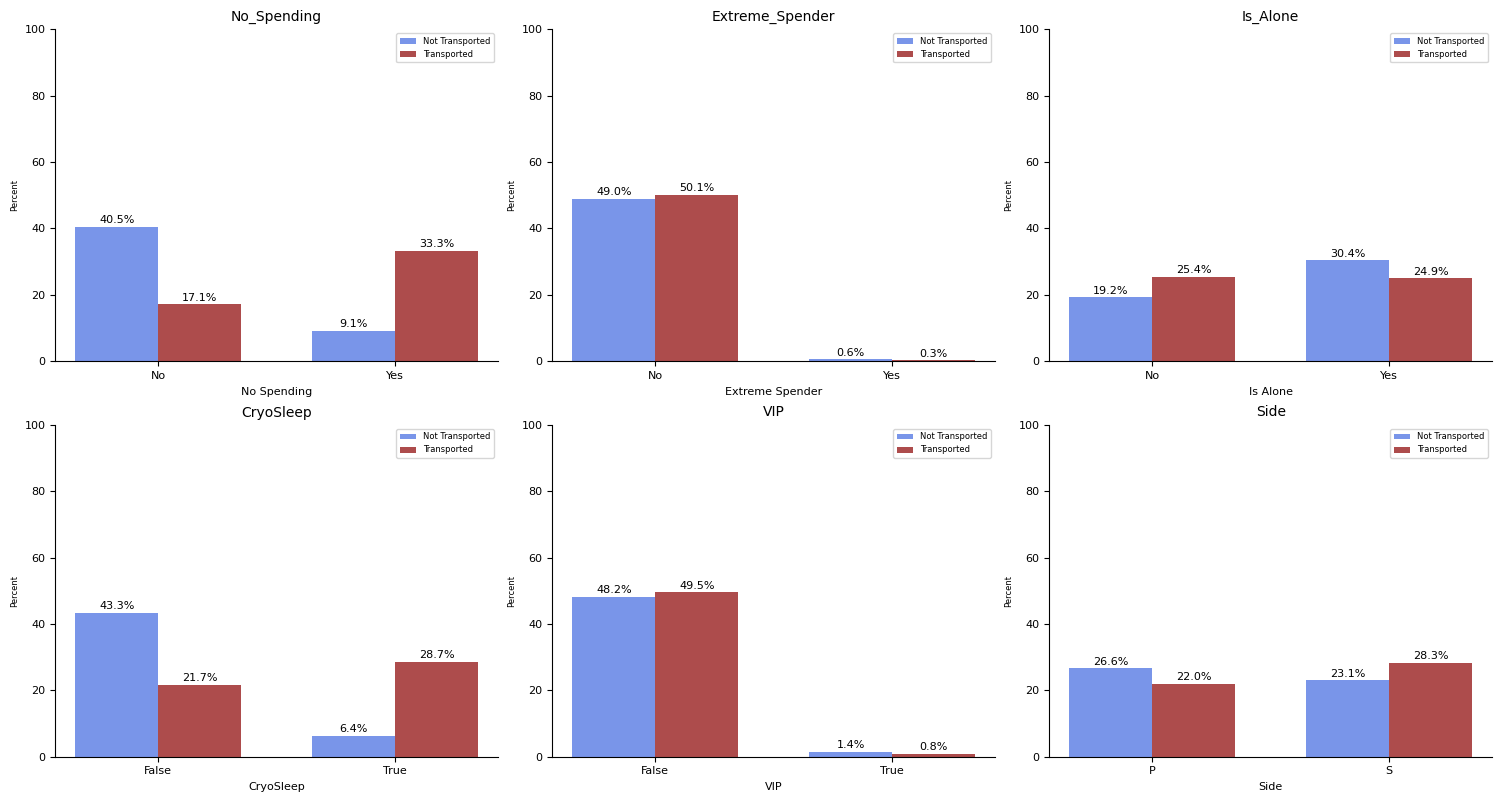

In [ ]:
warnings.filterwarnings('ignore')
binary_vars = ['No_Spending', 'Extreme_Spender', 'Is_Alone', 'CryoSleep', 'VIP', 'Side']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
temp_df = X_train.copy()
temp_df['Transported'] = y_train
for idx, var in enumerate(binary_vars):
    not_trans = temp_df[~temp_df['Transported']][var].value_counts().sort_index() / len(temp_df) * 100
    trans = temp_df[temp_df['Transported']][var].value_counts().sort_index() / len(temp_df) * 100
    if var == 'Side':
        labels = ['P', 'S']
    elif var == 'CryoSleep' or var == 'VIP':
        labels = ['False', 'True']
    else:
        labels = ['No', 'Yes']
    x = np.arange(len(labels))
    width = 0.35
    axes[idx].bar(x - width/2, not_trans, width, label='Not Transported', color='royalblue', alpha=0.7)
    axes[idx].bar(x + width/2, trans, width, label='Transported', color='darkred', alpha=0.7)
    for i, (p1, p2) in enumerate(zip(not_trans, trans)):
        axes[idx].text(i - width/2, p1 + 0.5, f'{p1:.1f}%', ha='center', va='bottom', fontsize=8)
        axes[idx].text(i + width/2, p2 + 0.5, f'{p2:.1f}%', ha='center', va='bottom', fontsize=8)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(labels)
    axes[idx].set_title(var, fontsize=10)
    axes[idx].set_ylabel('Percent')
    axes[idx].set_ylim(0, 100)
    axes[idx].tick_params(axis='both', labelsize=8)
    axes[idx].set_xlabel(var.replace('_', ' '), fontsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].legend(fontsize=6)
plt.tight_layout()
plt.show()

Among the binary features, No_Spending shows the clearest split, passengers who spent nothing are much more likely to be transported (~33%) than those who spent anything (~17%). Is_Alone has a smaller tilt toward not being transported. CryoSleep is the strongest variable with transported (~29%) far exceededing not transported (~6%). VIP and Extreme_Spender are rare and Side (P/S) shows only a mild difference.


3.4.3 Relationship between Categorical Variables and Target Variable

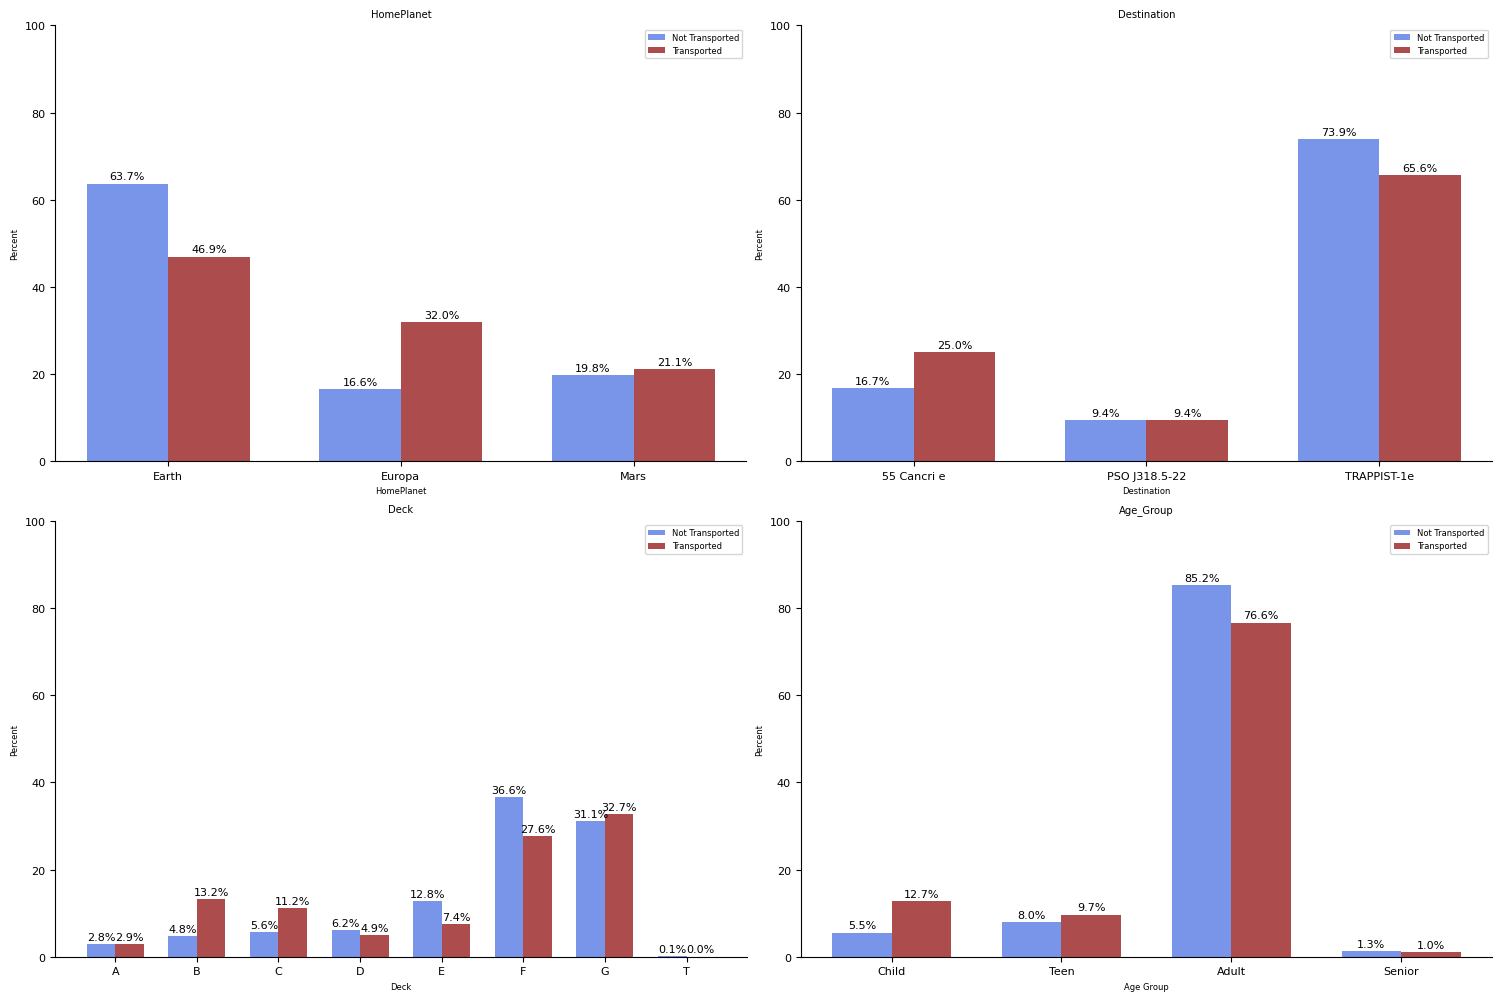

In [ ]:
warnings.filterwarnings('ignore')
categorical_vars = ['HomePlanet', 'Destination', 'Deck', 'Age_Group']
special_orders = {
    'Age_Group': ['Child', 'Teen', 'Adult', 'Senior'],
    'Deck': sorted(X_train['Deck'].unique())
}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
def plot_category(ax, var, data, categories):
    width = 0.35
    x = np.arange(len(categories))
    for transported, offset, color in [(False, -width/2, 'royalblue'), (True, width/2, 'darkred')]:
        mask = data['Transported'] == transported
        pcts = (data[mask][var].value_counts()
                .reindex(categories, fill_value=0)
                / mask.sum() * 100)
        ax.bar(x + offset, pcts, width, label=f'{"" if transported else "Not "}Transported', 
               color=color, alpha=0.7)
        for i, p in enumerate(pcts):
            ax.text(i + offset, p + 0.5, f'{p:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set(xticks=x, xticklabels=categories, ylabel='Percent', ylim=(0, 100),
           title=var, xlabel=var.replace('_', ' '))
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=6)
temp_df = X_train.copy()
temp_df['Transported'] = y_train
for idx, var in enumerate(categorical_vars):
    categories = special_orders.get(var, sorted(temp_df[var].unique()))
    plot_category(axes[idx], var, temp_df, categories)
plt.tight_layout()
plt.show()

Passengers from Earth show up more in the not transported group, while Europa appears more in the transported group (Mars is similar in both). For destination, TRAPPIST-1e makes up most of both groups, but 55 Cancri e is relatively more common among the transported, and PSO J318.5-22 is about the same. By deck, transported passengers cluster on B, C, and G, whereas E, F, and D have more not transported. For age group, children and teens form a larger share of the transported group. Adults dominate overall but are a smaller share among the transported.


**3.5 Correlation Matrix**

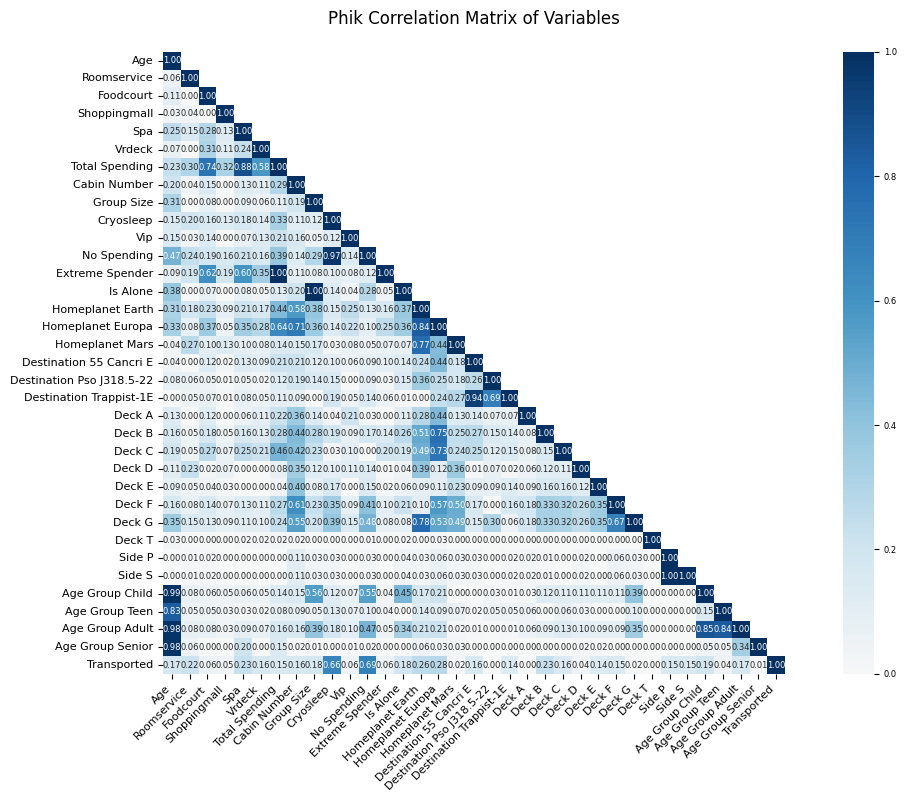

Correlations with Transported:
Age: 0.17
RoomService: 0.22
FoodCourt: 0.06
ShoppingMall: 0.05
Spa: 0.23
VRDeck: 0.16
Total_Spending: 0.15
Cabin_Number: 0.16
Group_Size: 0.18
CryoSleep: 0.66
VIP: 0.06
No_Spending: 0.69
Extreme_Spender: 0.06
Is_Alone: 0.18
HomePlanet_Earth: 0.26
HomePlanet_Europa: 0.28
HomePlanet_Mars: 0.02
Destination_55 Cancri e: 0.16
Destination_TRAPPIST-1e: 0.14
Deck_B: 0.23
Deck_C: 0.16
Deck_D: 0.04
Deck_E: 0.14
Deck_F: 0.15
Deck_G: 0.02
Side_P: 0.15
Side_S: 0.15
Age_Group_Child: 0.19
Age_Group_Teen: 0.04
Age_Group_Adult: 0.17
Age_Group_Senior: 0.01
Transported: 1.00


In [ ]:
cols = {
    'cat': ['HomePlanet', 'Destination', 'Deck', 'Side', 'Age_Group'],
    'num': ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'Total_Spending', 'Cabin_Number', 'Group_Size'],
    'bin': ['CryoSleep', 'VIP', 'No_Spending', 'Extreme_Spender', 'Is_Alone']
}
corr_df = pd.get_dummies(X_train.assign(Transported=y_train), columns=cols['cat'])
corr_df[cols['bin'] + ['Transported']] = corr_df[cols['bin'] + ['Transported']].astype(int)
encoded_cols = cols['num'] + cols['bin'] + [c for c in corr_df.columns if any(c.startswith(cat + '_') for cat in cols['cat'])] + ['Transported']
correlation_matrix = corr_df[encoded_cols].phik_matrix(interval_cols=cols['num'])
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            mask=np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1),
            annot=True, cmap='RdBu', center=0, fmt='.2f', square=True,
            xticklabels=[col.replace('_', ' ').title() for col in correlation_matrix.columns],
            yticklabels=[col.replace('_', ' ').title() for col in correlation_matrix.columns])
plt.title('Phik Correlation Matrix of Variables', fontsize=12, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("Correlations with Transported:")
for col in correlation_matrix.index:
    corr_value = correlation_matrix.loc[col, 'Transported']
    if abs(corr_value) > 0.01: 
        print(f"{col}: {corr_value:.2f}")

* No_Spending (0.69) and CryoSleep (0.66) show a strong correlation with being Transported as well. 
* HomePlanet, particularly Europa (0.28), shows moderate correlation with transport status. 
* The other Indepedent Variables show extremely low correlation with the Target Variable.

Now lets see if there are any significiant correlations between the Independent Variables:

In [ ]:

mask = np.triu(np.ones_like(correlation_matrix), k=1).astype(bool)
correlations = correlation_matrix.where(mask)
correlations_series = correlations.unstack()
correlations_series = correlations_series.dropna()
strongest_correlations = correlations_series.reindex(correlations_series.abs().sort_values(ascending=False).index)
for (var1, var2), corr_value in strongest_correlations.items():
    if abs(corr_value) > 0.6: 
        print(f"{var1} & {var2}: {corr_value:.2f}")

Is_Alone & Group_Size: 1.00
Side_S & Side_P: 1.00
Extreme_Spender & Total_Spending: 1.00
Age_Group_Child & Age: 0.99
Age_Group_Adult & Age: 0.98
Age_Group_Senior & Age: 0.98
No_Spending & CryoSleep: 0.97
Destination_TRAPPIST-1e & Destination_55 Cancri e: 0.94
Total_Spending & Spa: 0.88
Age_Group_Adult & Age_Group_Child: 0.85
Age_Group_Adult & Age_Group_Teen: 0.84
HomePlanet_Europa & HomePlanet_Earth: 0.84
Age_Group_Teen & Age: 0.83
Deck_G & HomePlanet_Earth: 0.78
HomePlanet_Mars & HomePlanet_Earth: 0.77
Deck_B & HomePlanet_Europa: 0.75
Total_Spending & FoodCourt: 0.74
Deck_C & HomePlanet_Europa: 0.73
HomePlanet_Europa & Cabin_Number: 0.71
Destination_TRAPPIST-1e & Destination_PSO J318.5-22: 0.69
Transported & No_Spending: 0.69
Deck_G & Deck_F: 0.67
Transported & CryoSleep: 0.66
HomePlanet_Europa & Total_Spending: 0.64
Extreme_Spender & FoodCourt: 0.62
Deck_F & Cabin_Number: 0.61
Extreme_Spender & Spa: 0.60


* The most significant findings are the strong correlations between No_Spending & CryoSleep (0.97). 
* Notable patterns also emerge in travel arrangements, with strong correlations between specific destinations (TRAPPIST-1e & 55 Cancri e: 0.94) and between home planets and deck assignments (Deck_B & Europa: 0.75, Deck_G & Earth: 0.78). Spending behaviors show consistent patterns, with Total_Spending strongly correlating with individual services (Spa: 0.88, FoodCourt: 0.74) and HomePlanet_Europa showing significant correlation with Total_Spending (0.64), suggesting distinct passenger segments based on their origin, accommodation, and spending habits.

### 4. STATISTICAL INFERENCE

**4.1 Target Population**

Our target population is passengers on the Spaceship Titanic.

**4.2 Statistical Hypotheses**

Based on the EDA, I have chosen to examine the relationship between the top 3 positively correlated Independent Variables and Target Variable: 

<u>Hypothesis 1: CryoSleep</u> 

* **Null Hypothesis (H0):** The proportion of passengers transported is the same for this in CryoSleep and those not in CryoSleep.
* **Alternative Hypothesis (H1):** The proportion of passengers transported differs between those in CryoSleep and those not in Cryosleep.

<u>Hypothesis 2: No Spending </u>

* **Null Hypothesis (H0):** There is no significant association between having zero spending and being transported.
* **Alternative Hypothesis (H1):** There is a significant association between having zero spending and being transported.

<u>Hypothesis 3: HomePlanet </u> - chi-square test

* **Null Hypothesis (H0):**  There is no significant association between HomePlanet and being transported. 
* **Alternative Hypothesis (H1):** There is a significant association between HomePlanet and being transported.

**4.3 Statistical Testing**

The following analysis examines each hypothesis through statistical testing, including significance levels, appropriate test selection, and confidence interval construction.

**4.3.1 <u>Hypothesis 1: CryoSleep </u>**

* **Significance level:** α = 0.05 (5%)

* **Test Selection:** Two-Sample Proportion Z-test (compares the proportion of passengers transported between those who were in CryoSleep and those who were not in CryoSleep). 

* **Assumptions:** (1) binary outcome (met as there is a true/false answer) and (2) large enough sample size (this is met as more than 10 in both groups). 

**Two-Sample Proportion Z-test**

In [ ]:
s = [y_train[X_train['CryoSleep']==1].sum(), y_train[X_train['CryoSleep']==0].sum()]
n = [(X_train['CryoSleep']==1).sum(), (X_train['CryoSleep']==0).sum()]
stat, p = proportions_ztest(s, n, alternative='two-sided')
print(f"Two-sample z-test: stat={stat:.4f}, p={p:.4f}")

Two-sample z-test: stat=38.5726, p=0.0000


The Two-Sample Proportion Z-test reveals a significant difference in transported rates between passengers in CryoSleep and those who are not. The large positive z-statistic (38.5726) indicates that passengers in CryoSleep are much more likely to be transported to an alternate dimension compared to those who are not in CryoSleep. This leads us to reject the null hypothesis and conclude that there is a strong statistical relationship. 

**Confidence Intervals**

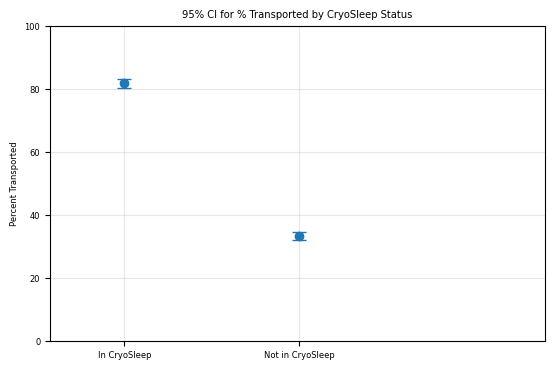

95% Confidence Intervals:
In CryoSleep: (80.3%, 83.3%)
Not in CryoSleep: (32.0%, 34.8%)


In [ ]:
x_pos = [-0.14, 0.0013]
labels = ['In CryoSleep', 'Not in CryoSleep']
props, errs = zip(*[
    (p := y_train[X_train['CryoSleep']==g].mean() * 100,
     [p - (ci := np.array(sm.stats.proportion_confint(
         y_train[X_train['CryoSleep']==g].sum(),
         (X_train['CryoSleep']==g).sum(),
         alpha=0.05, method='wilson')) * 100)[0],
      ci[1] - p])
    for g in [1, 0]
])

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar(x_pos, props, yerr=np.array(errs).T, fmt='o', capsize=5)
plt.xticks(x_pos, labels)
plt.title('95% CI for % Transported by CryoSleep Status')
plt.ylabel('Percent Transported')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()

print("95% Confidence Intervals:")
for l, p, (lo, up) in zip(labels, props, errs):
    print(f"{l}: ({p-lo:.1f}%, {p+up:.1f}%)")

The interval plot shows with 95% confidence that passengers in CryoSleep have a much higher transported rate (80.3%-83.3%) compared to those not in CryoSleep (32.0%-34.8%), with no overlap between intervals indicating a clear difference between groups, though both groups show similar levels of uncertainty in their estimates (approximately 3 percentage points).

**4.3.2 <u>Hypothesis 2: No Spending</u>**

* **Significance level:** α = 0.05 (5%)

* **Test Selection:** Two-Sample Proportion Z-test (compares the proportion of passengers transported between those who had no spending and those who had some spending).

* **Assumptions:** (1) binary outcome (met as there is a true/false answer) and (2) large enough sample size (this is met as more than 10 in both groups). 

**Two-Sample Proportion Z-test**

In [ ]:
s = [y_train[X_train['No_Spending']==1].sum(), y_train[X_train['No_Spending']==0].sum()]
n = [(X_train['No_Spending']==1).sum(), (X_train['No_Spending']==0).sum()]
stat, p = proportions_ztest(s, n, alternative='two-sided')
print(f"Two-sample z-test: stat={stat:.4f}, p={p:.4f}")

Two-sample z-test: stat=40.2313, p=0.0000


The Two-Sample Proportion Z-test reveals a significant difference in transported rates between passengers with no spending and those who spent money. The large positive z-statistic indicates that passengers who had no spending are much more likely to be transported to an alternate dimension compared to those who made purchases during their journey. This leads us to reject the null hypothesis and conclude that there is a strong statistical relationship. 

**Confidence Intervals**

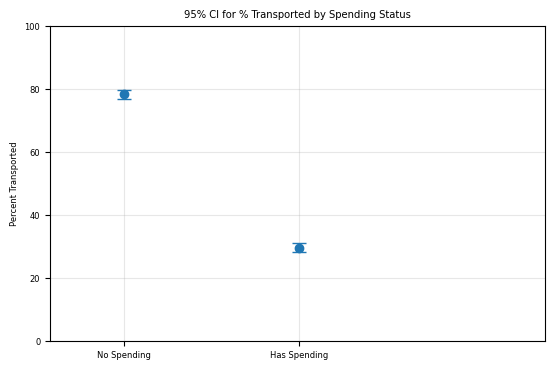

95% Confidence Intervals:
No Spending: (77.0%, 79.9%)
Has Spending: (28.3%, 31.1%)


In [ ]:
x_pos = [-0.14, 0.0013]
labels = ['No Spending', 'Has Spending']
props, errs = zip(*[
    (p := y_train[X_train['No_Spending']==g].mean() * 100,
     [p - (ci := np.array(sm.stats.proportion_confint(
         y_train[X_train['No_Spending']==g].sum(),
         (X_train['No_Spending']==g).sum(),
         alpha=0.05, method='wilson')) * 100)[0],
      ci[1] - p])
    for g in [1, 0]
])

plt.figure(figsize=(8,4))
plt.xlim(-0.2, 0.2)
plt.errorbar(x_pos, props, yerr=np.array(errs).T, fmt='o', capsize=5)
plt.xticks(x_pos, labels)
plt.title('95% CI for % Transported by Spending Status')
plt.ylabel('Percent Transported')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()

print("95% Confidence Intervals:")
for l, p, (lo, up) in zip(labels, props, errs):
    print(f"{l}: ({p-lo:.1f}%, {p+up:.1f}%)")

The interval plot shows with 95% confidence that passengers with no spending have a much higher transported rate (77.0%-79.9%) compared to those who made purchases (28.3%-31.1%), with no overlap between intervals indicating a clear difference between groups, though both groups show similar levels of uncertainty in their estimates (approximately 2.8 percentage points).

**4.3.3 <u>Hypothesis 3: HomePlanet</u>**

* **Significance level:** α = 0.05 (5%)

* **Test selection:** Chi-square Test of Independence (used to assess whether there is a significant association between HomePlanet and being transported)

* **Assumptions:** (1) the variables are categorical (HomePlanet is categorical and Transported is a binary categorical variables (True/False)) (2) the observations are independent (yes), (3) all cells have the expected frequency of at least 5 (yes)

**Chi-square test of Independence**

In [ ]:
contingency_table = pd.crosstab(X_train['HomePlanet'], y_train)
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

Chi-square statistic: 259.2314
p-value: 0.0000


The Chi-square test results (statistic=259.2314, p-value=0.0000) indicate a highly significant association between a passenger's home planet and transport status. The extremely small p-value (<0.05) leads us to reject the null hypothesis and conclude that there is a strong statistical relationship between a passenger's planet of origin and their likelihood of being transported.

**Confidence Intervals**

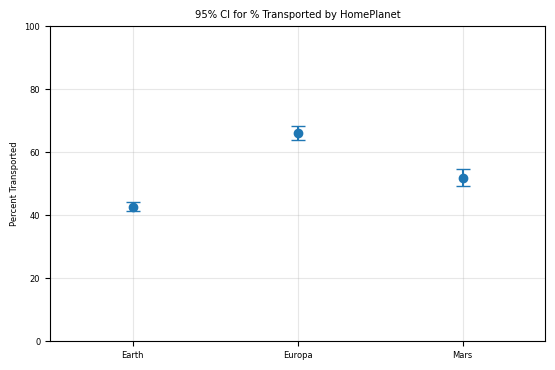

95% Confidence Intervals:
Earth: (41.2%, 44.4%)
Europa: (63.9%, 68.4%)
Mars: (49.4%, 54.6%)


In [ ]:
x_pos = [-0.2, 0, 0.2] 
labels = ['Earth', 'Europa', 'Mars']
props, errs = zip(*[
    (p := y_train[X_train['HomePlanet']==planet].mean() * 100,
     [p - (ci := np.array(sm.stats.proportion_confint(
         y_train[X_train['HomePlanet']==planet].sum(),
         (X_train['HomePlanet']==planet).sum(),
         alpha=0.05, method='wilson')) * 100)[0],
      ci[1] - p])
    for planet in labels
])

plt.figure(figsize=(8,4))
plt.xlim(-0.3, 0.3)
plt.errorbar(x_pos, props, yerr=np.array(errs).T, fmt='o', capsize=5)
plt.xticks(x_pos, labels)
plt.title('95% CI for % Transported by HomePlanet')
plt.ylabel('Percent Transported')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=3)
plt.subplots_adjust(right=0.7)
plt.show()

print("95% Confidence Intervals:")
for l, p, (lo, up) in zip(labels, props, errs):
    print(f"{l}: ({p-lo:.1f}%, {p+up:.1f}%)")

The interval plot shows with 95% confidence that transport rates vary significantly across home planets, with Europa having the highest transported rate (63.9%-68.4%), followed by Mars (49.4%-54.6%), and Earth having the lowest rate (41.2%-44.4%). The lack of overlap between these intervals indicates clear differences between all planet groups. Each planet group shows similar levels of uncertainty in their estimates (approximately 3-5 percentage points). Null hypothesis is rejected and alternative hypothesis is supported. 

### 5. MACHINE LEARNING MODELS

**5.1 Model Selection**

In [63]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(verbosity=-1,random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier() 
}

Next I train and evaluate the following models: (1) Logistic regression, (2) XGBoost, (3) LightGBM, (4) Support Vector Machine (SVM), (5) Random Forest and (6) K-Nearest Neighbors. These six models were selected to allow us to compare different approaches and select the best performing model. 

**5.2 Model Pipeline**

In [64]:
categorical_features = ['HomePlanet', 'Destination', 'Deck', 'Side']
log_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Total_Spending']
regular_numerical = ['Age', 'Cabin_Number', 'Group_Size']
binary_features = ['CryoSleep', 'VIP', 'No_Spending', 'Extreme_Spender', 'Is_Alone']

def log_transform(X):
    return np.log1p(X)

preprocessor_with_scaling = ColumnTransformer([
    ('log_num', Pipeline([
        ('log', FunctionTransformer(log_transform)),
        ('scaler', StandardScaler())
    ]), log_features),
    ('regular_num', StandardScaler(), regular_numerical),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
    ('bin', 'passthrough', binary_features)
])

preprocessor_without_scaling = ColumnTransformer([
    ('log_num', FunctionTransformer(log_transform), log_features),
    ('regular_num', 'passthrough', regular_numerical),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
    ('bin', 'passthrough', binary_features)
])

pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_with_scaling),
        ('classifier', models['Logistic Regression'])
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor_without_scaling),
        ('classifier', models['XGBoost'])
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor_without_scaling),
        ('classifier', models['LightGBM'])
    ]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor_with_scaling),
        ('classifier', models['SVM'])
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_without_scaling),
        ('classifier', models['Random Forest'])
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('preprocessor', preprocessor_with_scaling),
        ('classifier', models['K-Nearest Neighbors'])
    ])
}

Here I have implemented a preprocessing pipeline that combines encoding, scaling and log tranformation where applicable. 

**5.3 Model Fitting**

In [66]:
results = []
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_train)
    y_scores = pipeline.predict_proba(X_train)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_train, y_pred),
        'Precision': precision_score(y_train, y_pred, average='binary', zero_division=0),
        'Recall': recall_score(y_train, y_pred),
        'F1 Score': f1_score(y_train, y_pred, average='binary', zero_division=0),
        'ROC AUC': roc_auc_score(y_train, y_scores),
        'PR AUC': average_precision_score(y_train, y_scores)
    })

results_df = pd.DataFrame(results)
display(results_df.style.format({col: '{:.4f}' for col in results_df.columns if col != 'Model'}))


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Logistic Regression,0.7737,0.7682,0.7884,0.7782,0.8530,0.8711
1,XGBoost,0.9362,0.9259,0.9492,0.9374,0.9867,0.9865
2,LightGBM,0.8913,0.8872,0.8983,0.8927,0.9677,0.9683
3,SVM,0.8158,0.8043,0.8381,0.8209,0.8992,0.9070
4,Random Forest,0.9996,0.9994,0.9997,0.9996,1.0000,1.0000
5,K-Nearest Neighbors,0.8451,0.8642,0.8215,0.8423,0.9259,0.9140


With default settings, the almost-perfect scores from Random Forest (and, to a lesser extent, XGBoost) strongly suggest overfitting. LightGBM and K-NN show strong performance across metrics. Logistic Regression lags behind, which is expected given its linear decision boundary on a non-linear problem.

**Classification Report**

In [ ]:
for name, pipeline in pipelines.items():
    print(f"\nClassification Report for {name}:")
    print("="*50)
    y_pred = pipeline.predict(X_train)
    report = classification_report(y_train, y_pred, 
                                 target_names=['Not Transported', 'Transported'],
                                 digits=2)
    print(report)


Classification Report for Logistic Regression:
                 precision    recall  f1-score   support

Not Transported       0.78      0.76      0.77      3452
    Transported       0.77      0.79      0.78      3502

       accuracy                           0.77      6954
      macro avg       0.77      0.77      0.77      6954
   weighted avg       0.77      0.77      0.77      6954


Classification Report for XGBoost:
                 precision    recall  f1-score   support

Not Transported       0.95      0.92      0.93      3452
    Transported       0.93      0.95      0.94      3502

       accuracy                           0.94      6954
      macro avg       0.94      0.94      0.94      6954
   weighted avg       0.94      0.94      0.94      6954


Classification Report for LightGBM:
                 precision    recall  f1-score   support

Not Transported       0.90      0.88      0.89      3452
    Transported       0.89      0.90      0.89      3502

       accuracy 

**Confusion Matrices**

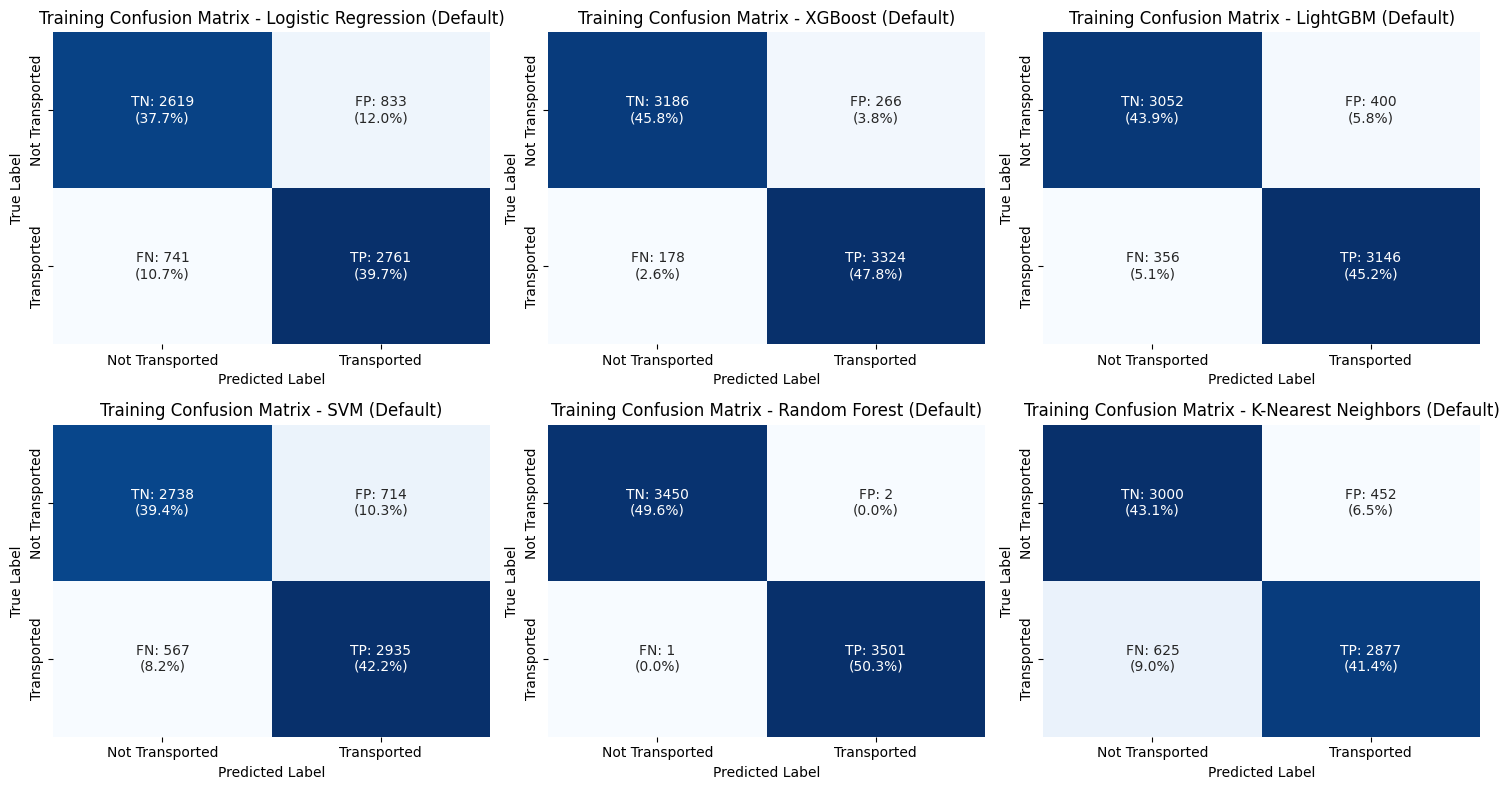

In [ ]:
class_names = ['Not Transported', 'Transported']  
m = len(pipelines)
cols = min(3, m)                         
rows = math.ceil(m / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.atleast_1d(axes).ravel()
for ax, (name, pipeline) in zip(axes, pipelines.items()):
    y_pred = pipeline.predict(X_train)
    cm = confusion_matrix(y_train, y_pred)
    total = cm.sum() or 1
    pct = cm / total * 100.0
    labels = np.array([
        [f"TN: {cm[0,0]}\n({pct[0,0]:.1f}%)", f"FP: {cm[0,1]}\n({pct[0,1]:.1f}%)"],
        [f"FN: {cm[1,0]}\n({pct[1,0]:.1f}%)", f"TP: {cm[1,1]}\n({pct[1,1]:.1f}%)"]
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Training Confusion Matrix - {name} (Default)')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
for ax in axes[m:]:
    ax.axis('off')
plt.tight_layout()
plt.show()


Random Forest is nearly perfect (1 FN, 2 FP). XGBoost has the next fewest errors and then LightGBM. The others make noticeably more mistakes. 


**5.4 Hyperparameter Tuning**

Based on these results, I will now perform hyperparameter tuning to enhance the top performing models through an iterative process. 

In [67]:
optuna.logging.set_verbosity(optuna.logging.CRITICAL)
models_default_tuned = results_df.copy()
models_default_tuned.columns = ['Model'] + [f'Default {c}' for c in results_df.columns[1:]]
round1 = lambda d: {k: (round(v, 1) if isinstance(v, float) else v) for k, v in d.items()}
def suggest_params(trial, model):
    n = model.lower()
    if n == 'logistic regression':
        return {'classifier__C': trial.suggest_float('classifier__C', 1e-2, 1e1, log=True),
                'classifier__penalty': trial.suggest_categorical('classifier__penalty', ['l1','l2']),
                'classifier__solver': trial.suggest_categorical('classifier__solver', ['liblinear','saga']),
                'classifier__class_weight': trial.suggest_categorical('classifier__class_weight', ['balanced', None])}
    if n == 'svm':
        return {'classifier__C': trial.suggest_float('classifier__C', 1e-1, 1e1, log=True),
                'classifier__kernel': trial.suggest_categorical('classifier__kernel', ['rbf','linear']),
                'classifier__gamma': trial.suggest_categorical('classifier__gamma', ['scale','auto']),
                'classifier__class_weight': trial.suggest_categorical('classifier__class_weight', ['balanced', None])}
    if n == 'xgboost':
        return {'classifier__max_depth': trial.suggest_int('classifier__max_depth', 3, 8),
                'classifier__learning_rate': trial.suggest_float('classifier__learning_rate', 0.01, 0.2),
                'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 150, 400),
                'classifier__min_child_weight': trial.suggest_int('classifier__min_child_weight', 1, 6),
                'classifier__gamma': trial.suggest_float('classifier__gamma', 0.0, 0.3),
                'classifier__subsample': trial.suggest_float('classifier__subsample', 0.6, 1.0),
                'classifier__colsample_bytree': trial.suggest_float('classifier__colsample_bytree', 0.6, 1.0),
                'classifier__reg_alpha': trial.suggest_float('classifier__reg_alpha', 0.0, 1.0),
                'classifier__reg_lambda': trial.suggest_float('classifier__reg_lambda', 0.0, 2.0)}
    if n == 'lightgbm':
        return {'classifier__num_leaves': trial.suggest_int('classifier__num_leaves', 31, 127),
                'classifier__max_depth': trial.suggest_int('classifier__max_depth', -1, 12),
                'classifier__learning_rate': trial.suggest_float('classifier__learning_rate', 0.01, 0.2),
                'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 150, 400),
                'classifier__min_child_samples': trial.suggest_int('classifier__min_child_samples', 10, 60),
                'classifier__subsample': trial.suggest_float('classifier__subsample', 0.6, 1.0),
                'classifier__colsample_bytree': trial.suggest_float('classifier__colsample_bytree', 0.6, 1.0),
                'classifier__reg_alpha': trial.suggest_float('classifier__reg_alpha', 0.0, 1.0),
                'classifier__reg_lambda': trial.suggest_float('classifier__reg_lambda', 0.0, 2.0)}
    if n == 'random forest':
        return {'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 200, 600),
                'classifier__max_depth': trial.suggest_int('classifier__max_depth', 8, 30),
                'classifier__min_samples_split': trial.suggest_int('classifier__min_samples_split', 2, 10),
                'classifier__min_samples_leaf': trial.suggest_int('classifier__min_samples_leaf', 1, 8),
                'classifier__max_features': trial.suggest_categorical('classifier__max_features', ['sqrt','log2', None]),
                'classifier__bootstrap': trial.suggest_categorical('classifier__bootstrap', [True, False])}
    if n == 'k-nearest neighbors':
        return {'classifier__n_neighbors': trial.suggest_int('classifier__n_neighbors', 3, 49),
                'classifier__weights': trial.suggest_categorical('classifier__weights', ['uniform','distance']),
                'classifier__p': trial.suggest_int('classifier__p', 1, 2)}
    return {}
def make_objective(name, base_pl):
    def _obj(trial):
        pl = clone(base_pl)
        params = suggest_params(trial, name)
        if params: pl.set_params(**params)
        pl.fit(X_train, y_train)
        return accuracy_score(y_train, pl.predict(X_train))
    return _obj

prob_scores = lambda est, X, y_pred: (
    est.predict_proba(X)[:,1] if hasattr(est,'predict_proba')
    else est.decision_function(X) if hasattr(est,'decision_function')
    else y_pred
)
tuned_rows, best_params_rows, best_params_dict = [], [], {}
for name, base_pl in pipelines.items():
    study = optuna.create_study(direction='maximize')
    study.optimize(make_objective(name, base_pl), n_trials=30, show_progress_bar=False)

    bp = study.best_params or {}
    best_params_dict[name] = bp
    bp_disp = round1(bp)                   
    print(f"\n{name} — Best Parameters:"); pprint(bp_disp)
    best_params_rows.append({"Model": name, **bp_disp})

    best_pl = clone(base_pl)
    if bp: best_pl.set_params(**bp)
    best_pl.fit(X_train, y_train)
    y_pred = best_pl.predict(X_train)
    s = prob_scores(best_pl, X_train, y_pred)
    tuned_rows.append({
        'Model': name,
        'Tuned Accuracy':  accuracy_score(y_train, y_pred),
        'Tuned Precision': precision_score(y_train, y_pred, zero_division=0),
        'Tuned Recall':    recall_score(y_train, y_pred),
        'Tuned F1 Score':  f1_score(y_train, y_pred, zero_division=0),
        'Tuned ROC AUC':   roc_auc_score(y_train, s),
        'Tuned PR AUC':    average_precision_score(y_train, s)
    })

final_comparison = pd.merge(models_default_tuned, pd.DataFrame(tuned_rows), on='Model')
metrics = ['Accuracy','Precision','Recall','F1 Score','ROC AUC','PR AUC']
improvements = pd.DataFrame({'Model': final_comparison['Model']})
for m in metrics:
    improvements[f'{m} Improvement'] = (final_comparison[f'Tuned {m}'] - final_comparison[f'Default {m}']).round(3)
display(final_comparison)
display(improvements)



Logistic Regression — Best Parameters:
{'classifier__C': 9.5,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l2',
 'classifier__solver': 'liblinear'}

XGBoost — Best Parameters:
{'classifier__colsample_bytree': 1.0,
 'classifier__gamma': 0.2,
 'classifier__learning_rate': 0.2,
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 1,
 'classifier__n_estimators': 322,
 'classifier__reg_alpha': 0.1,
 'classifier__reg_lambda': 1.3,
 'classifier__subsample': 0.9}

LightGBM — Best Parameters:
{'classifier__colsample_bytree': 0.8,
 'classifier__learning_rate': 0.2,
 'classifier__max_depth': 12,
 'classifier__min_child_samples': 22,
 'classifier__n_estimators': 223,
 'classifier__num_leaves': 100,
 'classifier__reg_alpha': 0.5,
 'classifier__reg_lambda': 0.7,
 'classifier__subsample': 0.8}

SVM — Best Parameters:
{'classifier__C': 10.0,
 'classifier__class_weight': None,
 'classifier__gamma': 'scale',
 'classifier__kernel': 'rbf'}

Random Forest — Best Parameters:
{

,Model,Default Accuracy,Default Precision,Default Recall,Default F1 Score,Default ROC AUC,Default PR AUC,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1 Score,Tuned ROC AUC,Tuned PR AUC
0,Logistic Regression,0.77,0.77,0.79,0.78,0.85,0.87,0.77,0.77,0.79,0.78,0.85,0.87
1,XGBoost,0.94,0.93,0.95,0.94,0.99,0.99,0.99,0.99,1.00,0.99,1.00,1.00
2,LightGBM,0.89,0.89,0.90,0.89,0.97,0.97,0.99,0.99,1.00,0.99,1.00,1.00
3,SVM,0.82,0.80,0.84,0.82,0.90,0.91,0.85,0.85,0.86,0.86,0.93,0.94
4,Random Forest,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
5,K-Nearest Neighbors,0.85,0.86,0.82,0.84,0.93,0.91,1.00,1.00,1.00,1.00,1.00,1.00


,Model,Accuracy Improvement,Precision Improvement,Recall Improvement,F1 Score Improvement,ROC AUC Improvement,PR AUC Improvement
0,Logistic Regression,0.00,0.00,-0.00,0.00,-0.00,-0.00
1,XGBoost,0.06,0.06,0.05,0.06,0.01,0.01
2,LightGBM,0.10,0.10,0.10,0.10,0.03,0.03
3,SVM,0.04,0.05,0.03,0.04,0.03,0.03
4,Random Forest,0.00,0.00,-0.00,-0.00,0.00,-0.00
5,K-Nearest Neighbors,0.15,0.14,0.18,0.16,0.07,0.09


From tuning, KNN has host the most significant increase. LightGBM has had the next most significant improvement in accuracy and across the other metrics and no improvement at all in Logistic Regression. 

**Classification Report**

In [106]:

class_names = ['Not Transported', 'Transported']
missing = [n for n in pipelines if n not in best_params_dict]
assert not missing, f"Missing tuned params for: {missing}"
for name, base_pl in pipelines.items():
    est = clone(base_pl)
    est.set_params(**best_params_dict[name])  #
    est.fit(X_train, y_train)                
    y_pred = est.predict(X_train)
    print("\n" + "="*80)
    print(f"{name} — Classification Report (TUNED, TEST)")
    print(classification_report(
        y_train, y_pred,
        labels=[0, 1],
        target_names=class_names,
        zero_division=0,
        digits=3
    ))


Logistic Regression — Classification Report (TUNED, TEST)
                 precision    recall  f1-score   support

Not Transported      0.779     0.761     0.770      3452
    Transported      0.770     0.787     0.778      3502

       accuracy                          0.774      6954
      macro avg      0.774     0.774     0.774      6954
   weighted avg      0.774     0.774     0.774      6954


XGBoost — Classification Report (TUNED, TEST)
                 precision    recall  f1-score   support

Not Transported      0.996     0.989     0.993      3452
    Transported      0.990     0.997     0.993      3502

       accuracy                          0.993      6954
      macro avg      0.993     0.993     0.993      6954
   weighted avg      0.993     0.993     0.993      6954


LightGBM — Classification Report (TUNED, TEST)
                 precision    recall  f1-score   support

Not Transported      0.996     0.988     0.992      3452
    Transported      0.988     0.996     

**Confusion Matrices**

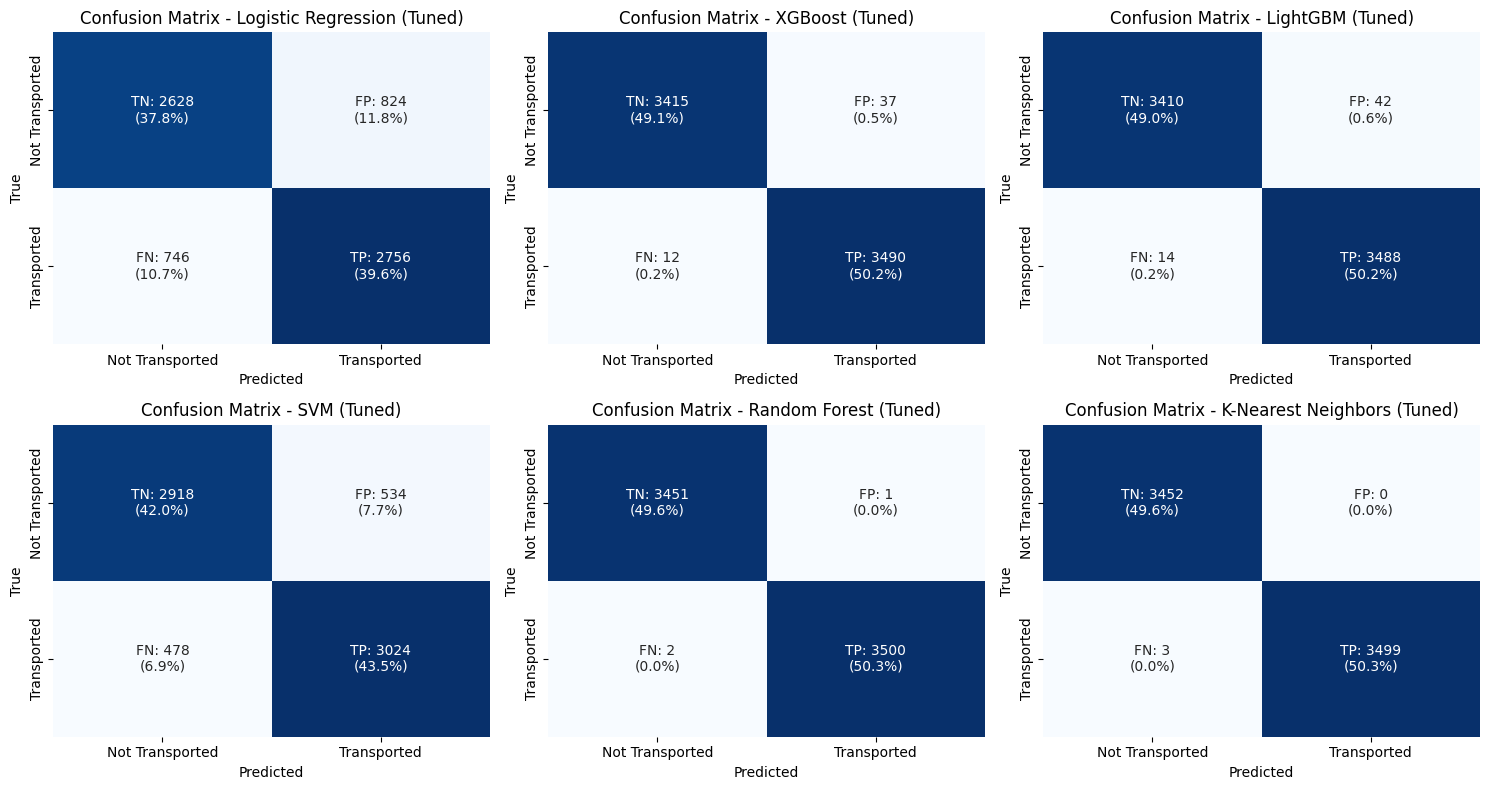

In [105]:
class_names = ['Not Transported', 'Transported']  
m = len(pipelines)
cols = min(3, m); rows = (m + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.atleast_1d(axes).ravel()

for ax, (name, base_pl) in zip(axes, pipelines.items()):
    est = clone(base_pl)
    params = best_params_dict.get(name, {})
    if params: est.set_params(**params)
    est.fit(X_train, y_train)
    y_pred = est.predict(X_train)
    cm = confusion_matrix(y_train, y_pred)
    pct = (cm / cm.sum() * 100) if cm.sum() else np.zeros_like(cm, float)
    labels = np.array([
        [f"TN: {cm[0,0]}\n({pct[0,0]:.1f}%)", f"FP: {cm[0,1]}\n({pct[0,1]:.1f}%)"],
        [f"FN: {cm[1,0]}\n({pct[1,0]:.1f}%)", f"TP: {cm[1,1]}\n({pct[1,1]:.1f}%)"]
    ])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix - {name} (Tuned)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for ax in axes[m:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**5.5 Model Ensembling**

In [77]:

set_config(transform_output="pandas")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=r".*max_iter.*", category=ConvergenceWarning)
for _, pl in pipelines.items():
    if isinstance(pl.named_steps.get('classifier'), LogisticRegression):
        pl.set_params(classifier__max_iter=5000, classifier__tol=1e-4)
skf = globals().get('skf') or StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
THRESHOLD, TOP_K, USE_ENSEMBLES = 0.79, 3, True
scoring = {
    'accuracy':'accuracy',
    'precision':make_scorer(precision_score, zero_division=0),
    'recall':make_scorer(recall_score, zero_division=0),
    'f1':make_scorer(f1_score, zero_division=0),
    'roc_auc':'roc_auc', 'pr_auc':'average_precision'
}
metrics_order = ['Accuracy','Precision','Recall','F1 Score','ROC AUC','PR AUC']
def has_proba(est):
    clf = getattr(est, 'named_steps', {}).get('classifier', est)
    return hasattr(clf, 'predict_proba')
def cv_row(name, est, variant):
    cv = cross_validate(est, X_train, y_train, scoring=scoring, cv=skf, n_jobs=-1)
    return {'Model':name,'Variant':variant,
            'Accuracy':cv['test_accuracy'].mean(),
            'Precision':cv['test_precision'].mean(),
            'Recall':cv['test_recall'].mean(),
            'F1 Score':cv['test_f1'].mean(),
            'ROC AUC':cv['test_roc_auc'].mean(),
            'PR AUC':cv['test_pr_auc'].mean()}

best_params = globals().get('best_params_dict')
default_models = {n: clone(pl) for n, pl in pipelines.items()}
tuned_models   = {n: clone(pl).set_params(**best_params.get(n, {})) if best_params else clone(pl)
                  for n, pl in pipelines.items()}
rows = [cv_row(n, m, 'Default') for n, m in default_models.items()]
rows += [cv_row(n, m, 'Tuned')   for n, m in tuned_models.items()]
if USE_ENSEMBLES:
    df_s = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
    def get_est(n, v): return tuned_models[n] if v=='Tuned' else default_models[n]
    cands = []
    for _, r in df_s.iterrows():
        est = get_est(r['Model'], r['Variant'])
        if has_proba(est): cands.append((r['Model'], r['Variant']))
        if len(cands) >= TOP_K: break
    def ens_label(c): return "Voting(" + "+".join(f"{m}[{v}]" for m,v in c) + ")"
    if len(cands) >= 2:
        rows.append(cv_row(ens_label(cands[:2]),
                           VotingClassifier([(m, get_est(m,v)) for m,v in cands[:2]], voting='soft'),
                           'Voting'))
    if len(cands) >= 3:
        rows.append(cv_row(ens_label(cands[:3]),
                           VotingClassifier([(m, get_est(m,v)) for m,v in cands[:3]], voting='soft'),
                           'Voting'))
leaderboard = pd.DataFrame(rows)
leaderboard = leaderboard[leaderboard['Accuracy'] >= THRESHOLD]
if leaderboard.empty:
    print(f"No models or ensembles reached Accuracy ≥ {THRESHOLD:.2f}.")
else:
    leaderboard = (leaderboard
        .round({k:4 for k in metrics_order})
        .sort_values('Accuracy', ascending=False)
        .loc[:, ['Model','Variant'] + metrics_order]
        .reset_index(drop=True))
    display(leaderboard)


,Model,Variant,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Voting(LightGBM[Default]+SVM[Default]),Voting,0.81,0.80,0.83,0.81,0.90,0.91
1,Voting(LightGBM[Default]+SVM[Default]+XGBoost[...,Voting,0.81,0.80,0.83,0.81,0.90,0.91
2,LightGBM,Default,0.80,0.81,0.80,0.81,0.90,0.91
3,SVM,Default,0.80,0.79,0.82,0.81,0.88,0.89
4,XGBoost,Default,0.80,0.80,0.79,0.80,0.89,0.91
5,Random Forest,Tuned,0.80,0.83,0.76,0.79,0.87,0.88
6,Random Forest,Default,0.80,0.82,0.76,0.79,0.88,0.89
7,LightGBM,Tuned,0.80,0.81,0.78,0.79,0.88,0.90
8,SVM,Tuned,0.80,0.79,0.81,0.80,0.88,0.89
9,XGBoost,Tuned,0.80,0.81,0.78,0.79,0.88,0.90


The soft voting ensemble came out with the combined models on top but these are challenging for interpreting feature importance. The best performing single model seems to be the default model of LightGBM with 80% on accuracy and performing best on the other secondary metrics as well. 

**Confusion Matrices**

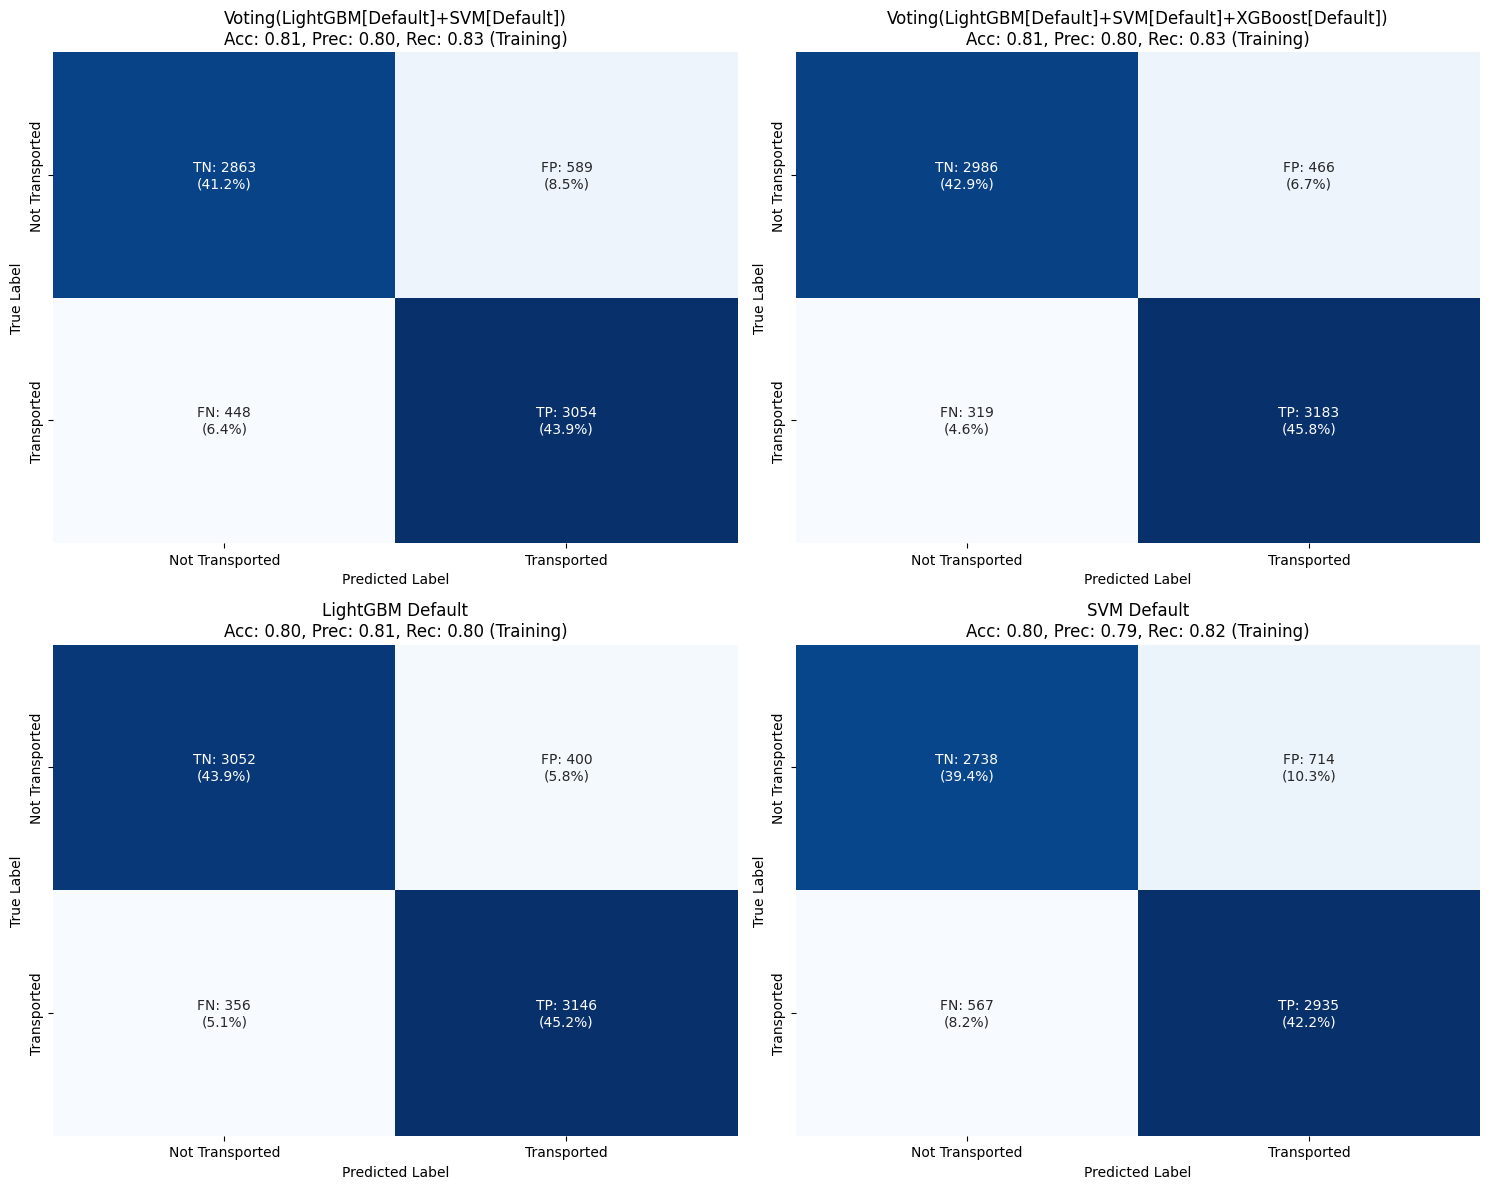

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

models_to_plot = [
    ("Voting(LightGBM[Default]+SVM[Default])", 
     VotingClassifier([(m, get_est(m,'Default')) for m,v in cands[:2]], voting='soft')),
    ("Voting(LightGBM[Default]+SVM[Default]+XGBoost[Default])", 
     VotingClassifier([(m, get_est(m,'Default')) for m,v in cands[:3]], voting='soft')),
    ("LightGBM Default", default_models['LightGBM']),
    ("SVM Default", default_models['SVM'])
]

for idx, (name, model) in enumerate(models_to_plot):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    cm = confusion_matrix(y_train, y_pred)
    total = cm.sum()
    
    labels = np.array([
        [f"TN: {cm[0,0]}\n({cm[0,0]/total*100:.1f}%)", f"FP: {cm[0,1]}\n({cm[0,1]/total*100:.1f}%)"],
        [f"FN: {cm[1,0]}\n({cm[1,0]/total*100:.1f}%)", f"TP: {cm[1,1]}\n({cm[1,1]/total*100:.1f}%)"]
    ])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Not Transported', 'Transported'],
                yticklabels=['Not Transported', 'Transported'], ax=axes[idx])
    
    if "Voting" in name:
        metrics = "Acc: 0.81, Prec: 0.80, Rec: 0.83"  
    elif "LightGBM" in name:
        metrics = "Acc: 0.80, Prec: 0.81, Rec: 0.80" 
    else: 
        metrics = "Acc: 0.80, Prec: 0.79, Rec: 0.82" 
    
    axes[idx].set_title(f'{name}\n{metrics} (Training)')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

LightGBM seems to have the least FP/FN than the others apart from the FN in the combined LightGBM, SVM and XGBoost model. 

**5.6 AutoML**

In [92]:
logging.getLogger('flaml').setLevel(logging.WARNING)  
automl = AutoML(verbose=0)  

automl.fit(X_train, y_train,
          task='classification',
          time_budget=240,  
          metric='accuracy',
          seed=42)

y_train_pred = automl.predict(X_train)
y_train_proba = automl.predict_proba(X_train)

metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC'],
    'Score': [
        round(accuracy_score(y_train, y_train_pred), 2),
        round(precision_score(y_train, y_train_pred), 2),
        round(recall_score(y_train, y_train_pred), 2),
        round(f1_score(y_train, y_train_pred), 2),
        round(roc_auc_score(y_train, y_train_proba[:, 1]), 2),
        round(average_precision_score(y_train, y_train_proba[:, 1]), 2)
    ]
}

model_details = {
    'Attribute': ['Best Model', 'Training Time (s)', 'Best Metric Score'],
    'Value': [
        str(automl.best_estimator),
        round(automl.best_config_train_time, 2),
        round(automl.best_loss, 2)
    ]
}
hyperparams = pd.DataFrame({
    'Parameter': list(automl.best_config.keys()),
    'Value': list(automl.best_config.values())
})

print("\nBest Model Details:")
display(pd.DataFrame(model_details))

print("AutoML Training Performance:")
display(pd.DataFrame(metrics_data))

print("\nBest Model Hyperparameters:")
display(hyperparams)


Best Model Details:


,Attribute,Value
0,Best Model,lgbm
1,Training Time (s),0.23
2,Best Metric Score,0.19


AutoML Training Performance:


,Metric,Score
0,Accuracy,0.83
1,Precision,0.82
2,Recall,0.85
3,F1 Score,0.84
4,ROC AUC,0.92
5,PR AUC,0.93



Best Model Hyperparameters:


,Parameter,Value
0,n_estimators,231.00
1,num_leaves,6.00
2,min_child_samples,8.00
3,learning_rate,0.09
4,log_max_bin,5.00
5,colsample_bytree,1.00
6,reg_alpha,0.02
7,reg_lambda,1.36


We now use a different technique to see if automl can detect the best performing model with minimal input from my end. The result is that LightGBM comes out on top here, which seems in line with tuning and model ensembling. Automl has produced a specific set of parameters which I may consider for applying to test set if the confusion matrix comes out well. 

**Confusion Matrix**

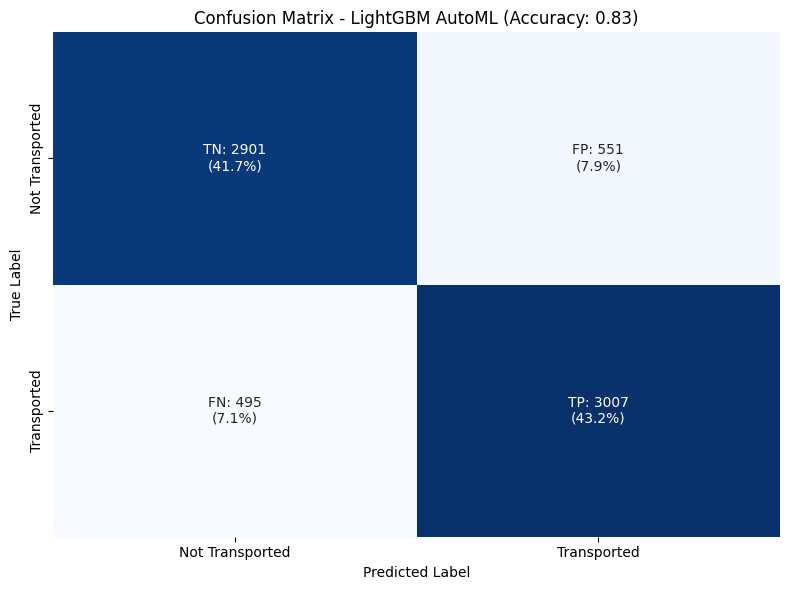

In [122]:
y_train_pred = automl.predict(X_train)

cm = confusion_matrix(y_train, y_train_pred)
total = cm.sum()

labels = np.array([
    [f"TN: {cm[0,0]}\n({cm[0,0]/total*100:.1f}%)", f"FP: {cm[0,1]}\n({cm[0,1]/total*100:.1f}%)"],
    [f"FN: {cm[1,0]}\n({cm[1,0]/total*100:.1f}%)", f"TP: {cm[1,1]}\n({cm[1,1]/total*100:.1f}%)"]
])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])

plt.title(f'Confusion Matrix - LightGBM AutoML (Accuracy: 0.83)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

The FN/FP do seem higher than before but there is an increase to 83% so it is worth trying this on the test set to see how well it generalises. 

**5.7 Model Performance**

LightGBM consistently emerges as the superior model. While both ensemble and default versions show strong performance, the automl LightGBM is selected as the optimal choice due highest accuracy metrics. Though the voting ensemble achieves comparable metrics, the single tuned LightGBM model offers the additional advantage of better interpretability, particularly for feature importance analysis, making it more valuable for understanding the underlying patterns in passenger transportation predictions.

In [218]:
automl_lgbm = Pipeline([
    ('preprocessor', preprocessor_without_scaling),
    ('classifier', LGBMClassifier(
        n_estimators=231,        
        num_leaves=6,             
        min_child_samples=8,       
        learning_rate=0.09,        
        log_max_bin=5,            
        colsample_bytree=1.0,     
        reg_alpha=0.02,           
        reg_lambda=1.36,          
        random_state=42
    ))
])

automl_lgbm.fit(X_train, y_train)
y_pred = automl_lgbm.predict(X_test)
y_scores = automl_lgbm.predict_proba(X_test)[:, 1]
test_results = {
    'Model': 'AutoML LightGBM (Test)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_scores),
    'PR AUC': average_precision_score(y_test, y_scores)
}

display(pd.DataFrame([test_results]))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,AutoML LightGBM (Test),0.81,0.80,0.82,0.81,0.91,0.92


The 81% result on accuracy did not vary too much from the training set result, meaning fine generalisation. 

**Classification Report**

In [223]:
print("\nClassification Report (Test) — Automl LightGBM:")
print(classification_report(
    y_test, y_pred,
    target_names=['Not Transported', 'Transported'],
    digits=3, zero_division=0
))


Classification Report (Test) — Automl LightGBM:
                 precision    recall  f1-score   support

Not Transported      0.814     0.790     0.802       863
    Transported      0.799     0.822     0.810       876

       accuracy                          0.806      1739
      macro avg      0.806     0.806     0.806      1739
   weighted avg      0.806     0.806     0.806      1739



**Confusion Matrices**

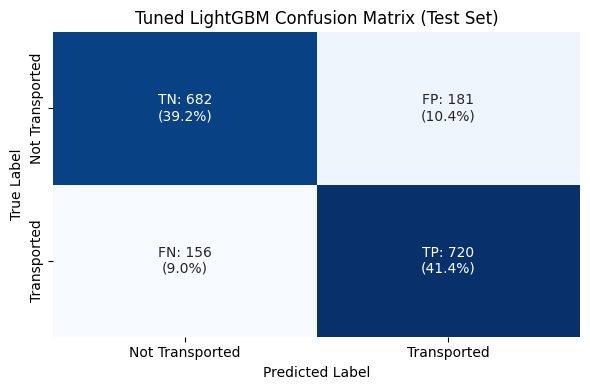

In [220]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
total = cm.sum()
labels = np.array([
    [f"TN: {cm[0,0]}\n({cm[0,0]/total*100:.1f}%)", f"FP: {cm[0,1]}\n({cm[0,1]/total*100:.1f}%)"],
    [f"FN: {cm[1,0]}\n({cm[1,0]/total*100:.1f}%)", f"TP: {cm[1,1]}\n({cm[1,1]/total*100:.1f}%)"]
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title('Tuned LightGBM Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

The percentages of FN/FP are higher than in the training set, which is a bit quite normal on a test set. 

**5.8 Feature Importance Analysis**

**SHAP**

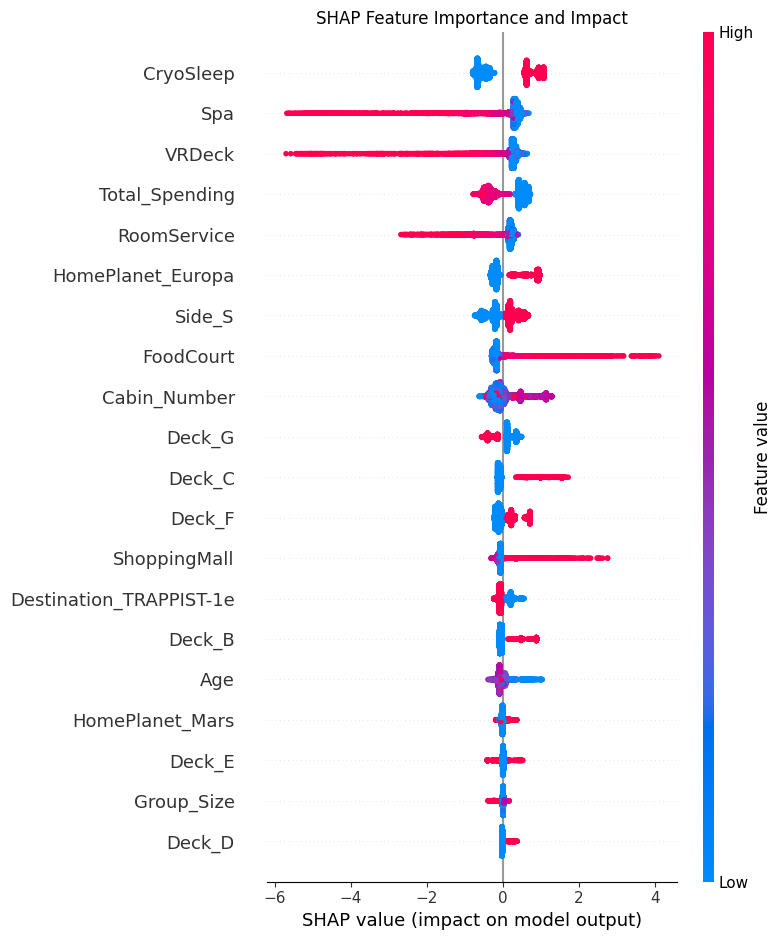

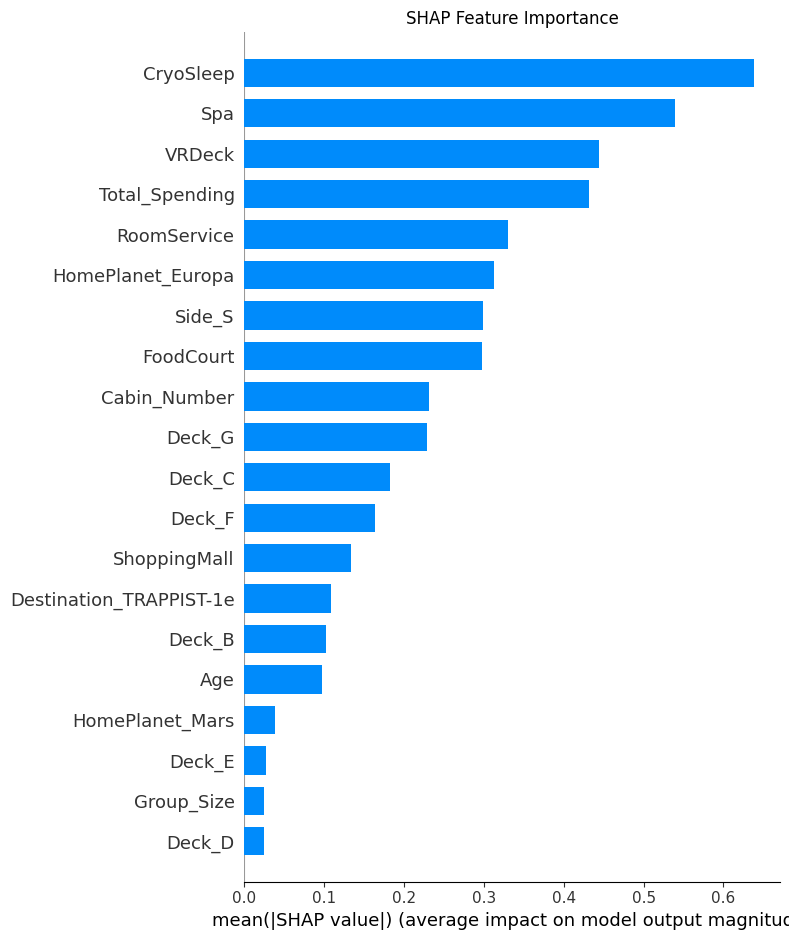


Feature Importance Rankings (SHAP):


,Feature,SHAP Importance
21,CryoSleep,0.64
3,Spa,0.54
4,VRDeck,0.44
5,Total_Spending,0.43
0,RoomService,0.33
9,HomePlanet_Europa,0.31
20,Side_S,0.30
1,FoodCourt,0.30
7,Cabin_Number,0.23
18,Deck_G,0.23


In [ ]:
X_train_transformed = automl_lgbm.named_steps['preprocessor'].transform(X_train)
cat_features = automl_lgbm.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = np.concatenate([
    log_features,          
    regular_numerical,     
    cat_features,          
    binary_features        
])
explainer = shap.TreeExplainer(
    automl_lgbm.named_steps['classifier'],
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_train_transformed)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Feature Importance and Impact")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Importance': np.abs(shap_values).mean(0)
}).sort_values('SHAP Importance', ascending=False)

print("\nFeature Importance Rankings (SHAP):")
display(shap_importance.round(4))

The biggest takeaway here is that those in Cryosleep had a high impact on being transported. Those who spent less in Spa, VRDeck, Roomservice were most likely to be transported. HomePlanet Europa seems to be the most influential of the departure planets. 

**5.9 Generating Submission Predictions on Test Data**

In [ ]:
if 'X_valid' in globals() and 'y_valid' in globals():
    X_thr, y_thr = X_valid, y_valid
elif 'X_val' in globals() and 'y_val' in globals():
    X_thr, y_thr = X_val, y_val
else:
    X_thr, _, y_thr, _ = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
X_thr_trans = preprocessor_without_scaling.transform(X_thr)
clf = automl_lgbm.named_steps['classifier']
pos_idx = int(np.where(clf.classes_ == 1)[0][0]) if hasattr(clf, "classes_") else 1
proba_thr = clf.predict_proba(X_thr_trans)[:, pos_idx]
grid = np.linspace(0.20, 0.80, 601)
best_t, best_acc = max(((t, accuracy_score(y_thr, proba_thr >= t)) for t in grid), key=lambda x: x[1])
print(f"Chosen threshold: {best_t:.3f}")
test_df_transformed = preprocessor_without_scaling.transform(test_df)
test_proba = clf.predict_proba(test_df_transformed)[:, pos_idx]
test_predictions = (test_proba >= best_t)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_predictions.astype(bool)
})
submission.to_csv('submission.csv', index=False)
print("\nSubmission preview:")
print(submission.head())
print("Submission shape:", submission.shape)

Chosen threshold: 0.499

Submission preview:
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
Submission shape: (4277, 2)


I achieved a result of 80.43% on Kaggle after 5 attempts. I added in some threshold optimisation code in there which improved the result massively. 

### 6. CONCLUSION & IMPROVEMENTS

**6.1 Conclusions**
- Primary Predictive Factors:
    - Passengers in Cryosleep more likely to be transported. 
    - Passengers who spent less more likely to be transport was the best performing model and also good for interpretability. 


**6.2 Improvements**
- Implement a model deployment for real-time preditions (e.g. Streamlit/ Google Cloud)
- Extend AutoML exploration beyond the current 4 minutes to longer (e.g. 1 hour), this may produce even better model results. 
- Look into using a validation dataset to better aaddress overfitting concerns 
- Explore deeper variable interactions and their impact on predictions 
- Added threshold optimisation earlier in the project on a validation set or just training set. I added right at the end to increase result of Kaggle entry. 